Notebook to generate the figures in the readme.md

In [1]:
from viz import * 
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd 
import matplotlib as mpl
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
from shapely.geometry import Polygon, MultiPolygon
import dataframe_image as dfi
from epiweeks import Week 
from aux_func import get_data, color_palette, estado_para_regiao, rename_models

# Definir a cor das bordas (spines) como cinza
mpl.rcParams['axes.edgecolor'] = 'gray'

# Definir a cor das linhas dos ticks maiores e menores como cinza
mpl.rcParams['xtick.color'] = 'gray'
mpl.rcParams['ytick.color'] = 'gray'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'
plt.rcParams['axes.labelsize'] = 16 # Axis labels
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick labels
plt.rcParams['font.size'] = 16  # General font size
FONT = 12

In [2]:
challenge = 'dengue_city'

In [3]:
df_dengue = get_data(challenge)
df_dengue.date = pd.to_datetime(df_dengue.date)

df_dengue.head()

,date,adm_2,casos
0,2010-01-03,3549805,187
1,2010-01-03,3541406,4
2,2010-01-03,2302503,0
3,2010-01-03,5201405,399
4,2010-01-03,1716109,16


In [4]:
df_preds = pd.read_csv(f'./predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds['model'] = df_preds['model'].replace(rename_models)
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_2,id,validation,wis,model
0,2022-10-09,0.0,0.0,0.0,0.000000,0.263369,0.752038,2.204613,2.548759,3.217477,2931350,13696,1,9.91,EMAP_PROPHET
1,2022-10-16,0.0,0.0,0.0,0.000000,0.305167,0.864584,2.260565,2.571846,2.903148,2931350,13696,1,9.91,EMAP_PROPHET
2,2022-10-23,0.0,0.0,0.0,0.000000,0.356236,0.934832,2.347639,2.838857,3.055871,2931350,13696,1,9.91,EMAP_PROPHET
3,2022-10-30,0.0,0.0,0.0,0.000000,0.329178,0.977098,2.329630,3.129482,3.404810,2931350,13696,1,9.91,EMAP_PROPHET
4,2022-11-06,0.0,0.0,0.0,0.019425,0.438958,1.068266,2.553999,3.291094,4.628868,2931350,13696,1,9.91,EMAP_PROPHET


In [5]:
df_muni = gpd.read_file('../imdc_2026/data/shape_muni.gpkg')
df_muni = df_muni.loc[df_muni.geocode.isin(df_dengue.adm_2)]
df_muni.head(15)

,geocode,geocode_name,uf,uf_code,geometry
57,1200203,Cruzeiro do Sul,AC,12,"MULTIPOLYGON (((-72.58477 -7.552, -72.90031 -7..."
66,1200401,Rio Branco,AC,12,"MULTIPOLYGON (((-67.61015 -10.04805, -67.5807 ..."
401,1716109,Paraíso do Tocantins,TO,17,"MULTIPOLYGON (((-48.8843 -10.31861, -48.8797 -..."
921,2302503,Brejo Santo,CE,23,"MULTIPOLYGON (((-38.96254 -7.60564, -38.96144 ..."
2214,2931350,Teixeira de Freitas,BA,29,"MULTIPOLYGON (((-39.72129 -17.28062, -39.73264..."
2239,2933307,Vitória da Conquista,BA,29,"MULTIPOLYGON (((-40.71677 -14.88782, -40.71745..."
2456,3119401,Coronel Fabriciano,MG,31,"MULTIPOLYGON (((-42.6245 -19.53288, -42.61952 ..."
3731,3541406,Presidente Prudente,SP,35,"MULTIPOLYGON (((-51.40335 -22.03094, -51.41691..."
3823,3549805,São José do Rio Preto,SP,35,"MULTIPOLYGON (((-49.40563 -20.90772, -49.39177..."
3963,4103701,Cambé,PR,41,"MULTIPOLYGON (((-51.23506 -23.28564, -51.2347 ..."


In [6]:
df_rank = pd.read_csv(f'predictions/rank_ratio_{challenge}.csv')

df_rank['model'] = df_rank['model'].replace(rename_models)

df_rank['rank'] = df_rank.groupby(['validation', 'adm_2'])['wis_ratio'].rank(ascending=True, method='min')
#df_rank['region'] = df_rank['region'].replace(rename_regions)

df_rank.head()

,model,adm_2,validation,wis,wis_baseline,wis_ratio,rank
0,EMAP_PROPHET,1200203,1,8.57,7.10,1.207042,3.0
1,EMAP_PROPHET,1200203,2,10.45,7.88,1.326142,4.0
2,EMAP_PROPHET,1200203,3,27.61,34.39,0.802850,4.0
3,EMAP_PROPHET,1200203,4,8.60,8.20,1.048780,3.0
4,EMAP_PROPHET,1200401,1,7.31,11.30,0.646903,2.0


In [7]:
df_rank.model.unique()

<ArrowStringArray>
[ 'EMAP_PROPHET',  'EMAP_SARIMAX',     'EMAP_LSTM',      'EMAP_XGB',
     'EMAP_BLUE',           'ISI',      'NUS-CERM',        'PURDUE',
         'UNESP', 'UNI_DEL_VALLE']
Length: 10, dtype: str

## Plot overall performance:

EMAP_PROPHET


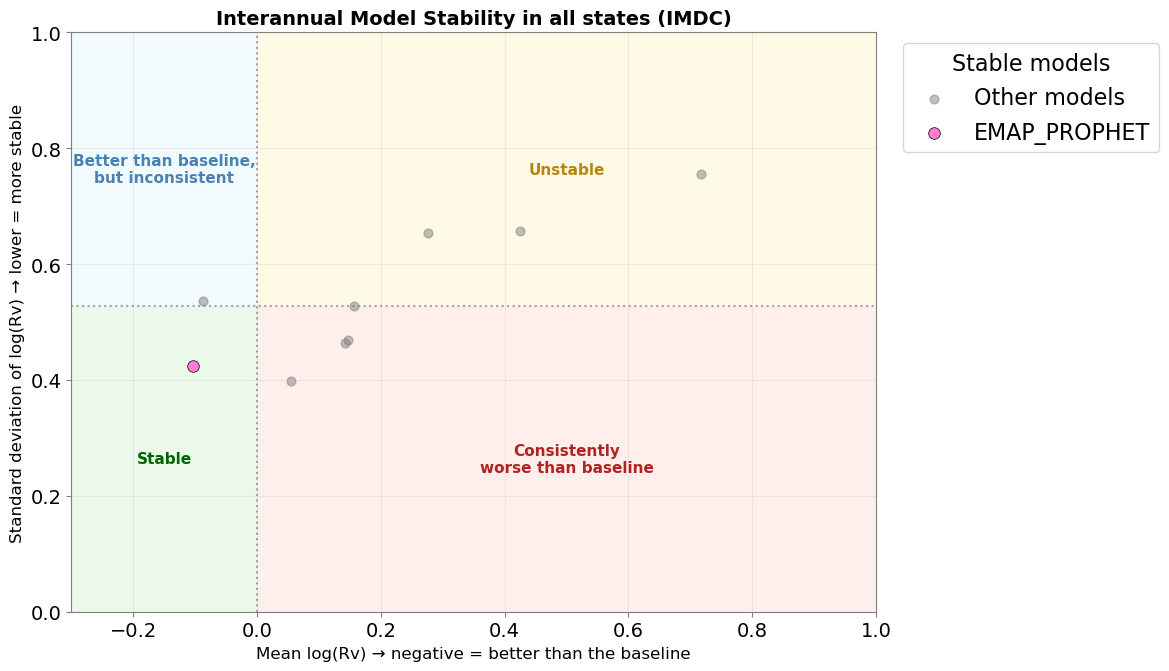

In [8]:
fig, ax, df_agg = plot_model_scatter(
    df_rank,
    rename_models=rename_models,
    baseline_model="EMAP_LSTM",
    exclude_adm1=None,
    title="Interannual Model Stability in all states (IMDC)",
    xlabel="Mean log(Rv) → negative = better than the baseline",
    ylabel="Standard deviation of log(Rv) → lower = more stable",
    xlim=(-0.3, 1),
    ylim=(0, 1),
    figsize=(12, 7),
    savepath=f'figures/scatter_stable_{challenge}.png',
    color_palette=color_palette)

### Violin plots:

/home/eduardocorrea/Documentos/analises_3rd_IMDC/viz.py:900: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


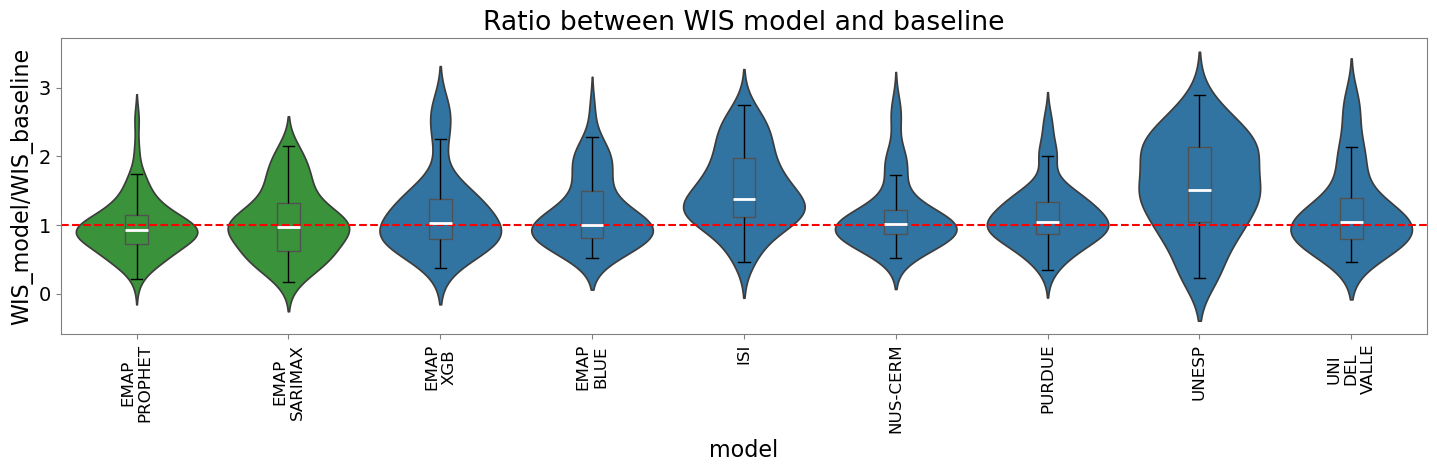

(<Figure size 1500x500 with 1 Axes>,
 <Axes: title={'center': 'Ratio between WIS model and baseline'}, xlabel='model', ylabel='WIS_model/WIS_baseline'>)

In [9]:
plot_violin(df_rank.loc[df_rank.model != 'EMAP_LSTM'], region = None, challenge=challenge)

### Heatmaps

In [10]:
df_summary = (
    df_rank
    .groupby(["adm_2", "model"], as_index=False)
    .agg(
        geometric_mean_ratio=("wis_ratio", lambda x: np.exp(np.mean(np.log(x)))),
    )
    .sort_values(["adm_2", "geometric_mean_ratio"])
)

column = 'geometric_mean_ratio'

df_summary["rank"] = (
    df_summary.groupby(["adm_2"])[[column]].rank(method="min", ascending=True)
)

df_summary = df_summary.merge(df_muni[['geocode', 'geocode_name']], left_on = 'adm_2', right_on = 'geocode' )
df_summary['uf'] = df_summary['geocode'].astype(str).str[:2].astype(int).replace(code_to_state)
df_summary['adm_2_name'] = df_summary['geocode_name'].astype(str) + ' - ' + df_summary['uf']
df_summary.head()

,adm_2,model,geometric_mean_ratio,rank,geocode,geocode_name,uf,adm_2_name
0,1200203,EMAP_LSTM,1.000000,1.0,1200203,Cruzeiro do Sul,AC,Cruzeiro do Sul - AC
1,1200203,EMAP_SARIMAX,1.042110,2.0,1200203,Cruzeiro do Sul,AC,Cruzeiro do Sul - AC
2,1200203,EMAP_PROPHET,1.077477,3.0,1200203,Cruzeiro do Sul,AC,Cruzeiro do Sul - AC
3,1200203,UNI_DEL_VALLE,1.299124,4.0,1200203,Cruzeiro do Sul,AC,Cruzeiro do Sul - AC
4,1200203,EMAP_BLUE,1.491114,5.0,1200203,Cruzeiro do Sul,AC,Cruzeiro do Sul - AC


In [11]:
df_summary.adm_2_name.unique()

<ArrowStringArray>
[      'Cruzeiro do Sul - AC',            'Rio Branco - AC',
  'Paraíso do Tocantins - TO',           'Brejo Santo - CE',
   'Teixeira de Freitas - BA',  'Vitória da Conquista - BA',
    'Coronel Fabriciano - MG',   'Presidente Prudente - SP',
 'São José do Rio Preto - SP',                 'Cambé - PR',
              'Cascavel - PR',              'Londrina - PR',
 'Campo Novo do Parecis - MT',  'Aparecida de Goiânia - GO',
             'Novo Gama - GO']
Length: 15, dtype: str

In [12]:
regions =  ['Cascavel - PR', 'Londrina - PR', 'Cambé - PR',
      'Coronel Fabriciano - MG',   'Presidente Prudente - SP',
      'São José do Rio Preto - SP', 
       'Campo Novo do Parecis - MT',  'Aparecida de Goiânia - GO',
             'Novo Gama - GO', 
         'Brejo Santo - CE',
   'Teixeira de Freitas - BA',  'Vitória da Conquista - BA',
             'Cruzeiro do Sul - AC',            'Rio Branco - AC',
  'Paraíso do Tocantins - TO',
                  
]

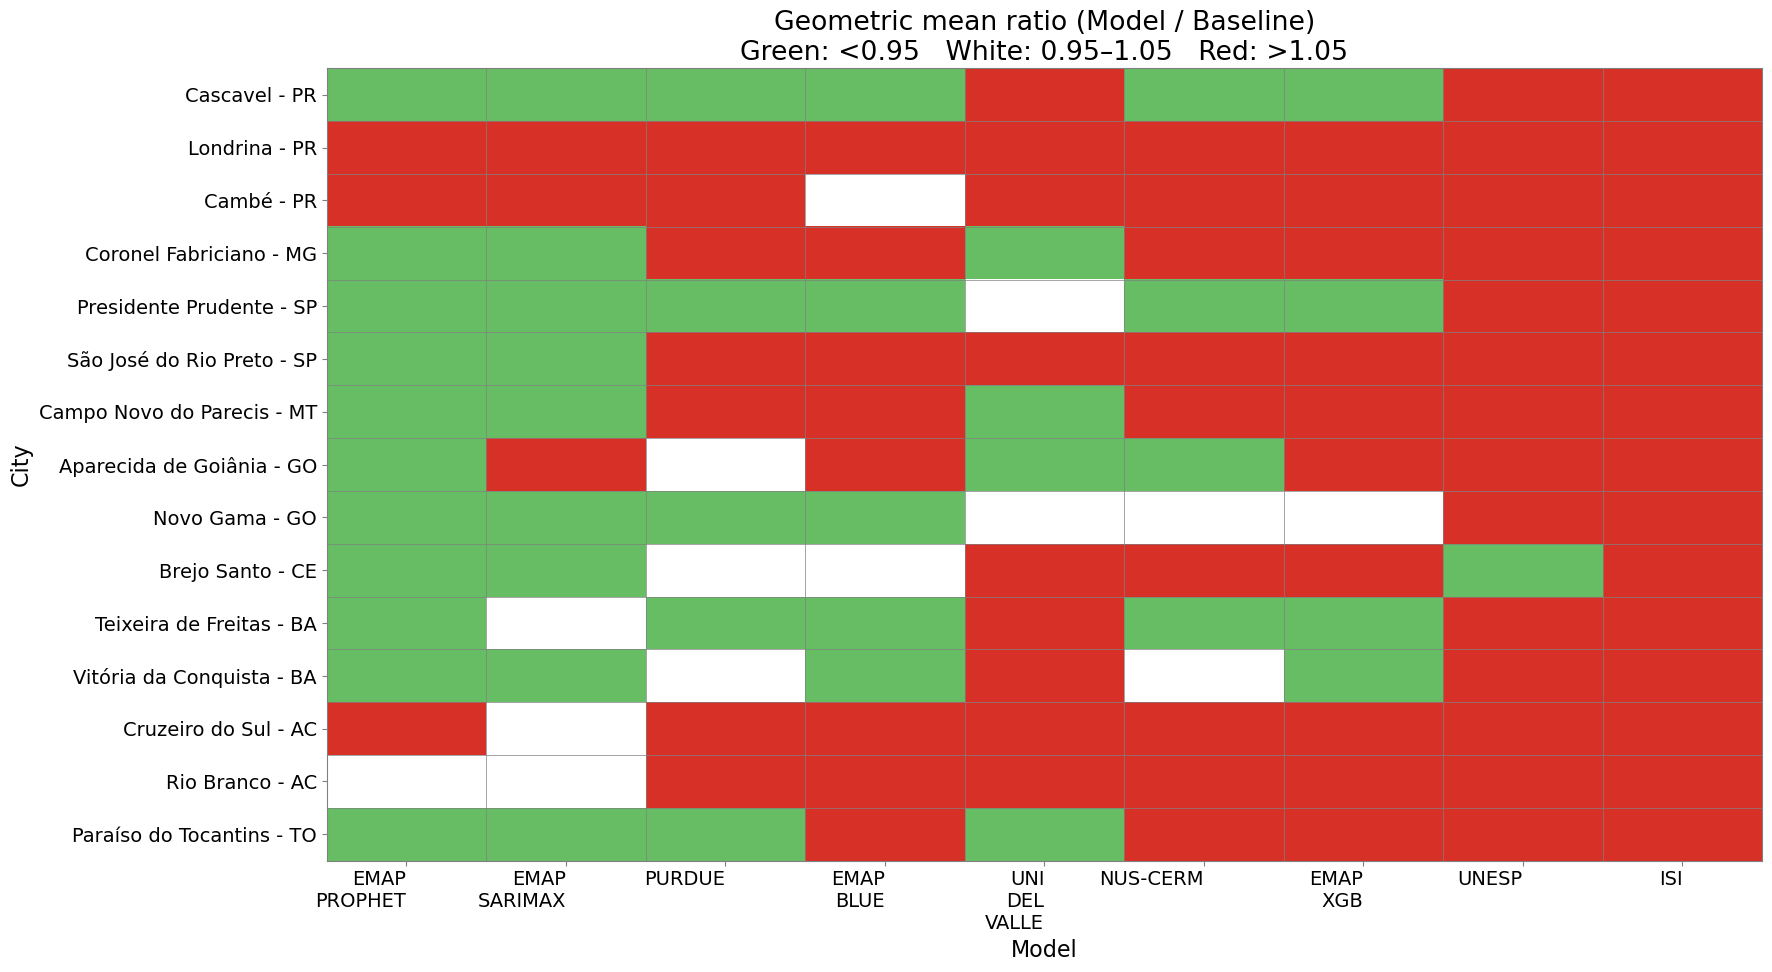

In [13]:
ranking = plot_matrix(df_summary.loc[ (df_summary.model != 'EMAP_LSTM')],
                      regions,
        figsize=(18, 10),
        challenge=challenge,
        transpose=False,
            col = 'adm_2_name',
            xlabel = 'City',
                rotation = 0, 
    region_sep = False)

In [14]:
plot_geometric_ratio_heatmap(
        df_summary.loc[ (df_summary.model != 'EMAP_LSTM')],
        regions,
        '',
        figsize=(25, 10),
        challenge=challenge,
        col = 'adm_2_name',
            ylabel = 'city',
            rotation = 0
    )

## Plots Best models by state: 

In [15]:
df_summary.model.unique()

<ArrowStringArray>
[    'EMAP_LSTM',  'EMAP_SARIMAX',  'EMAP_PROPHET', 'UNI_DEL_VALLE',
     'EMAP_BLUE',      'EMAP_XGB',        'PURDUE',         'UNESP',
           'ISI',      'NUS-CERM']
Length: 10, dtype: str

In [16]:
df_bm_st = df_summary.loc[df_summary['rank'] ==1].rename(columns = {'model': 'best_model'})
df_bm_st['state'] = df_bm_st['adm_2'].replace(code_to_state)

df_bm_st.head()

,adm_2,best_model,geometric_mean_ratio,rank,geocode,geocode_name,uf,adm_2_name,state
0,1200203,EMAP_LSTM,1.000000,1.0,1200203,Cruzeiro do Sul,AC,Cruzeiro do Sul - AC,1200203
10,1200401,EMAP_PROPHET,0.960728,1.0,1200401,Rio Branco,AC,Rio Branco - AC,1200401
20,1716109,EMAP_SARIMAX,0.643359,1.0,1716109,Paraíso do Tocantins,TO,Paraíso do Tocantins - TO,1716109
30,2302503,UNESP,0.664653,1.0,2302503,Brejo Santo,CE,Brejo Santo - CE,2302503
40,2931350,PURDUE,0.829582,1.0,2931350,Teixeira de Freitas,BA,Teixeira de Freitas - BA,2931350


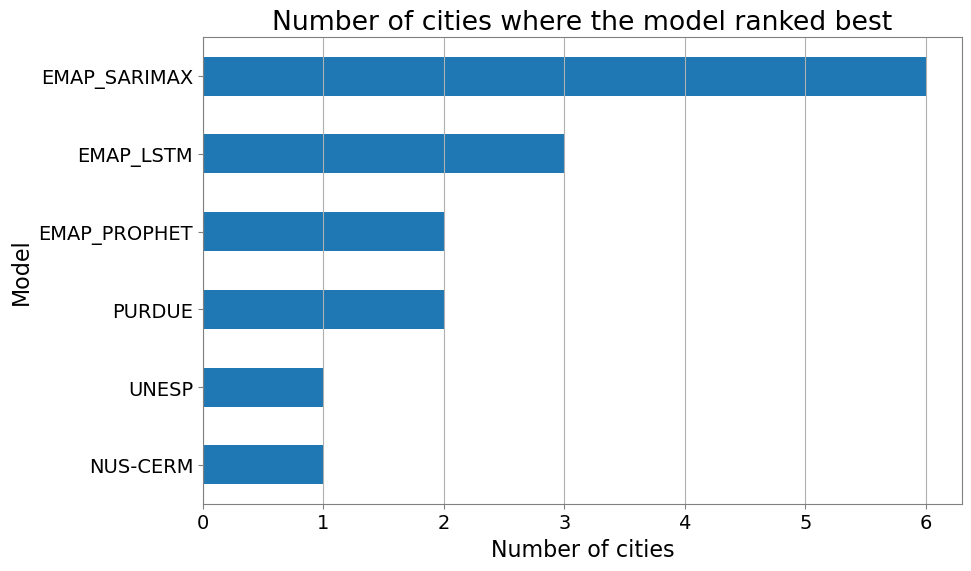

In [17]:
barplot_best_models(
    df_bm_st,
    challenge=challenge,
    model_col="best_model",
    xlabel="Number of cities",
    ylabel="Model",
    title="Number of cities where the model ranked best",) 

In [18]:
df_bm_st

,adm_2,best_model,geometric_mean_ratio,rank,geocode,geocode_name,uf,adm_2_name,state
0,1200203,EMAP_LSTM,1.000000,1.0,1200203,Cruzeiro do Sul,AC,Cruzeiro do Sul - AC,1200203
10,1200401,EMAP_PROPHET,0.960728,1.0,1200401,Rio Branco,AC,Rio Branco - AC,1200401
20,1716109,EMAP_SARIMAX,0.643359,1.0,1716109,Paraíso do Tocantins,TO,Paraíso do Tocantins - TO,1716109
30,2302503,UNESP,0.664653,1.0,2302503,Brejo Santo,CE,Brejo Santo - CE,2302503
40,2931350,PURDUE,0.829582,1.0,2931350,Teixeira de Freitas,BA,Teixeira de Freitas - BA,2931350
50,2933307,EMAP_SARIMAX,0.753119,1.0,2933307,Vitória da Conquista,BA,Vitória da Conquista - BA,2933307
60,3119401,EMAP_SARIMAX,0.880017,1.0,3119401,Coronel Fabriciano,MG,Coronel Fabriciano - MG,3119401
70,3541406,PURDUE,0.750260,1.0,3541406,Presidente Prudente,SP,Presidente Prudente - SP,3541406
80,3549805,EMAP_SARIMAX,0.885485,1.0,3549805,São José do Rio Preto,SP,São José do Rio Preto - SP,3549805
90,4103701,EMAP_LSTM,1.000000,1.0,4103701,Cambé,PR,Cambé - PR,4103701


### Models with mean ratio >1 

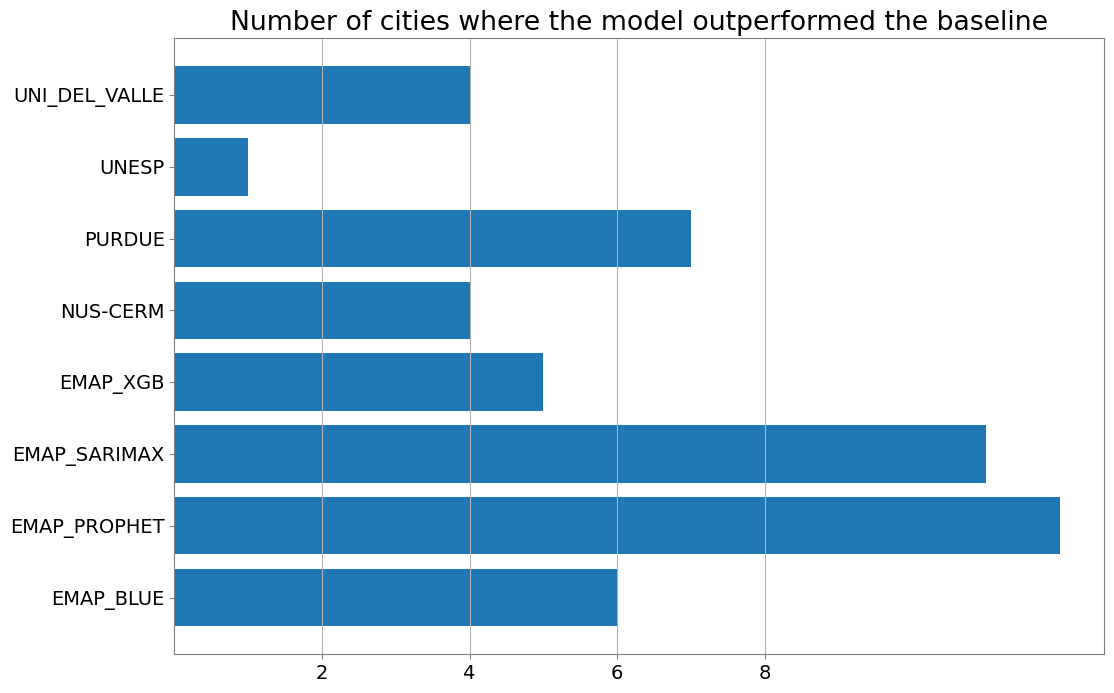

In [19]:
df_agg = df_summary.loc[ (df_summary.model != 'EMAP_LSTM')].loc[df_summary.geometric_mean_ratio < 1].groupby(['model'])[['adm_2_name']].count()

_, ax= plt.subplots(figsize = (12, 8))

ax.barh(df_agg.index, df_agg.adm_2_name)

ax.grid(axis = 'x')
ax.set_title('Number of cities where the model outperformed the baseline')
ax.set_xticks(np.arange(2, 10, step = 2))

plt.savefig(f'figures/n_cities_out_base_by_model_{challenge}.png', dpi = 300, bbox_inches = 'tight')

plt.show()

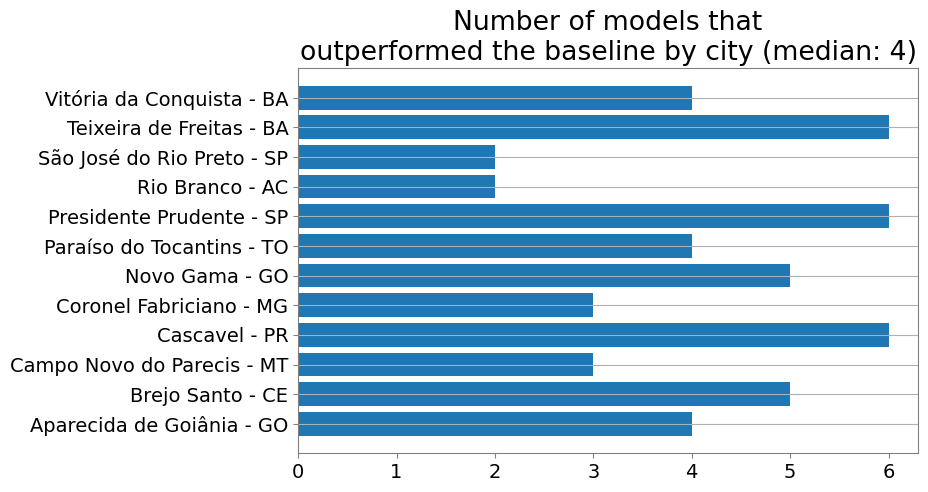

In [20]:
df_agg = df_summary.loc[ (df_summary.model != 'EMAP_LSTM')].loc[df_summary.geometric_mean_ratio < 1].groupby(['adm_2_name'])[['model']].count().reset_index()
df_agg['adm_2_name'] = df_agg['adm_2_name'].replace(code_to_state)

# Cria a coluna de região e ordena

# Plotagem
_, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_agg.adm_2_name, df_agg.model)
ax.set_title(f'Number of models that\noutperformed the baseline by city (median: {int(np.median(df_agg.model))})')

ax.grid(axis='y')

plt.savefig(f'figures/n_models_out_base_by_city_{challenge}.png', dpi = 300, bbox_inches = 'tight')

In [21]:
df_summary.loc[df_summary['rank'] == 1][['adm_2_name', 'model']]

,adm_2_name,model
0,Cruzeiro do Sul - AC,EMAP_LSTM
10,Rio Branco - AC,EMAP_PROPHET
20,Paraíso do Tocantins - TO,EMAP_SARIMAX
30,Brejo Santo - CE,UNESP
40,Teixeira de Freitas - BA,PURDUE
50,Vitória da Conquista - BA,EMAP_SARIMAX
60,Coronel Fabriciano - MG,EMAP_SARIMAX
70,Presidente Prudente - SP,PURDUE
80,São José do Rio Preto - SP,EMAP_SARIMAX
90,Cambé - PR,EMAP_LSTM


### Zoom: 

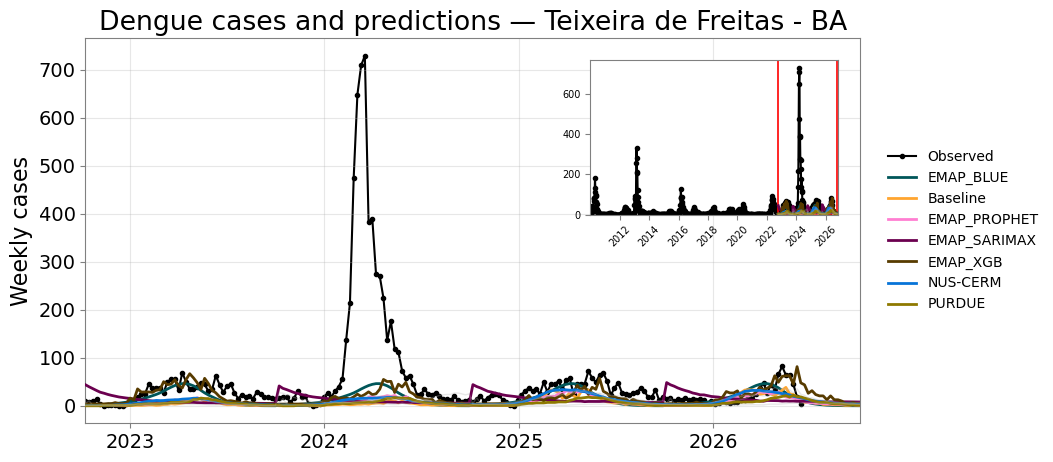

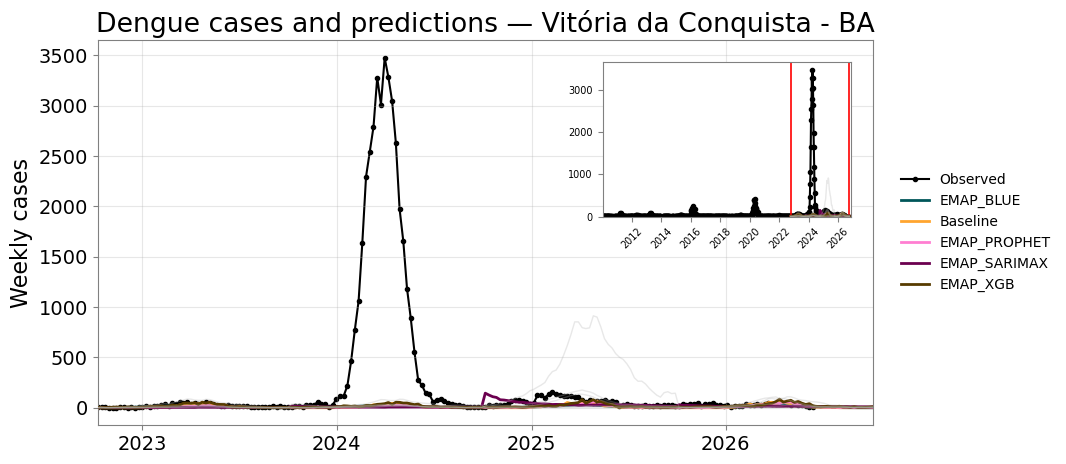

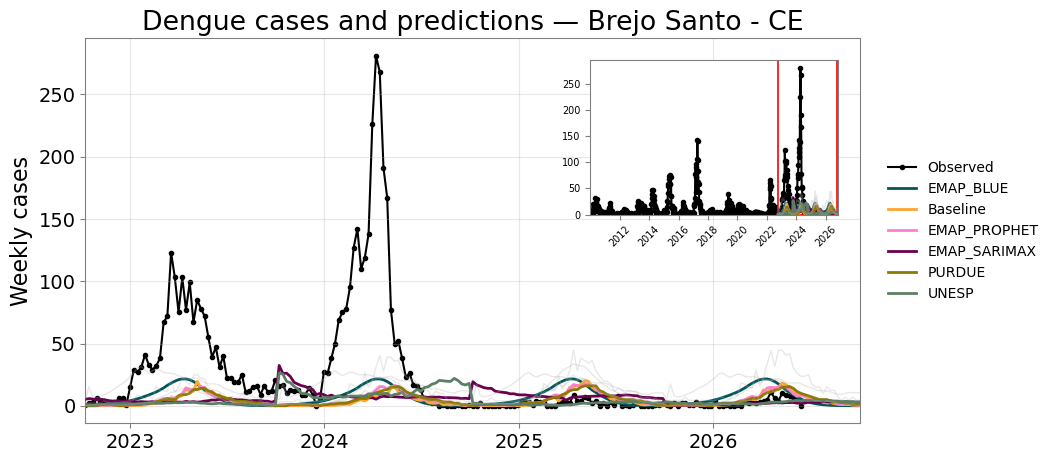

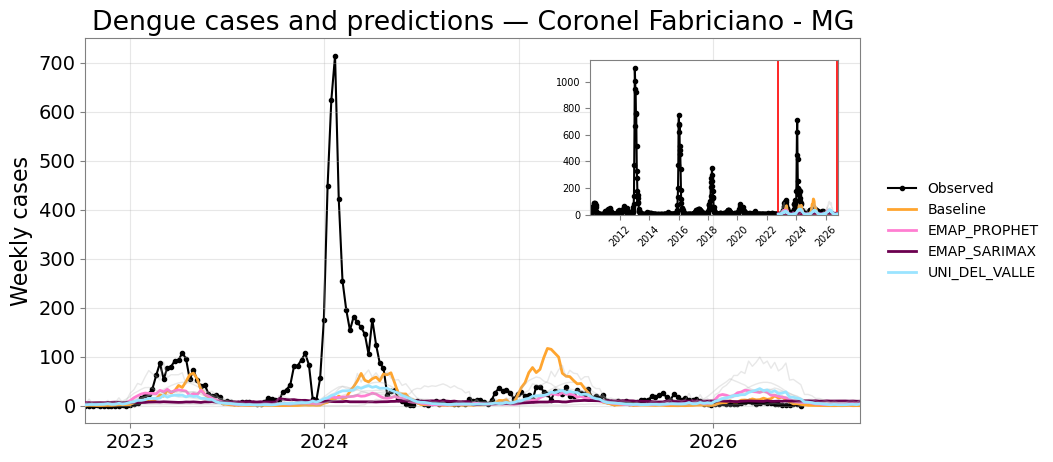

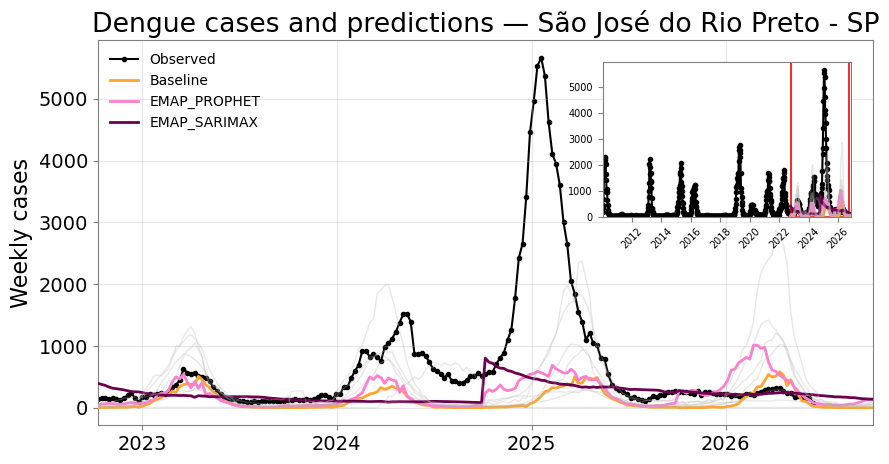

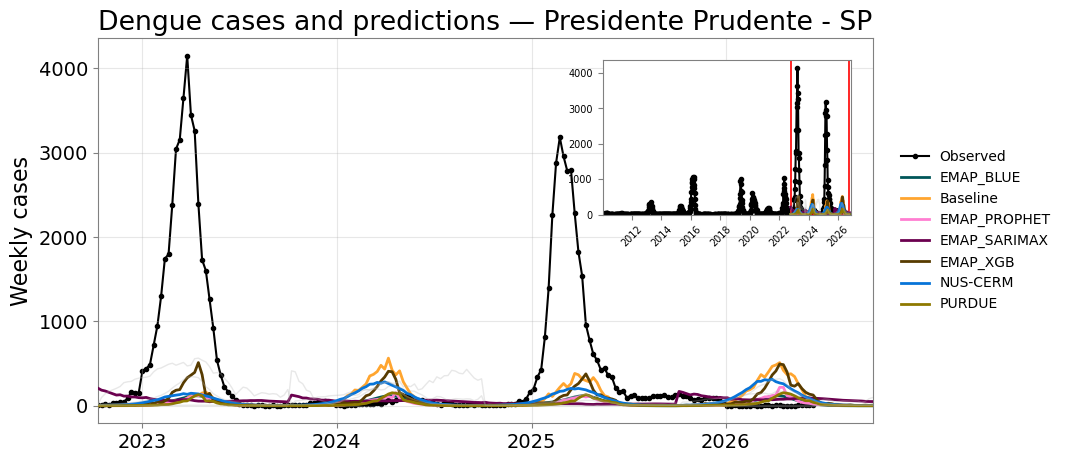

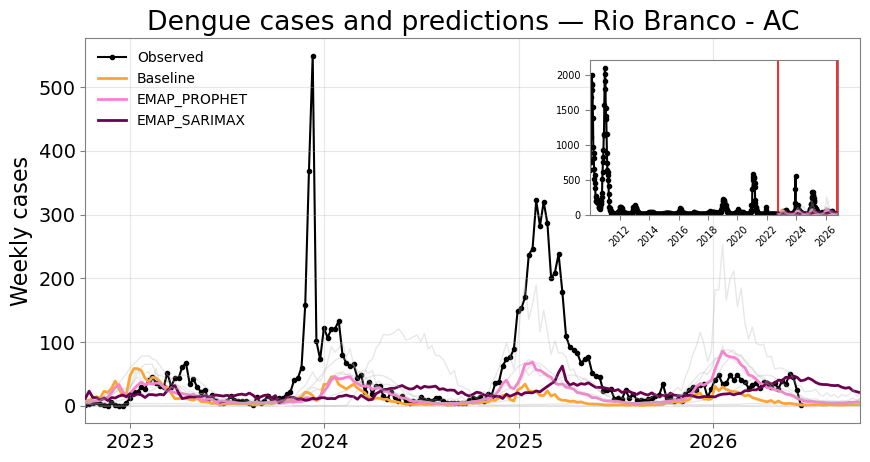

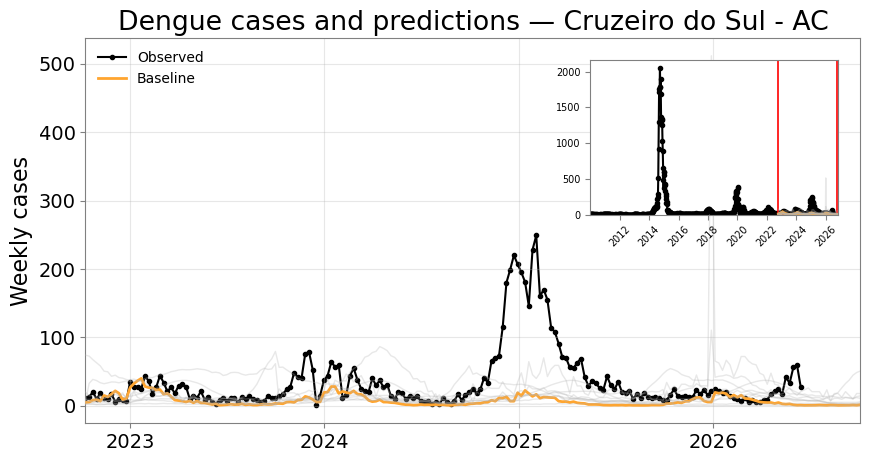

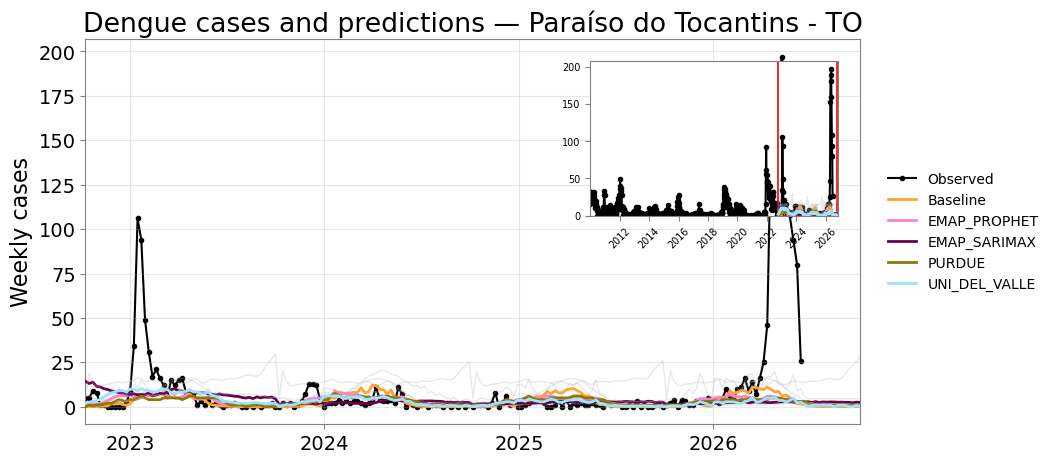

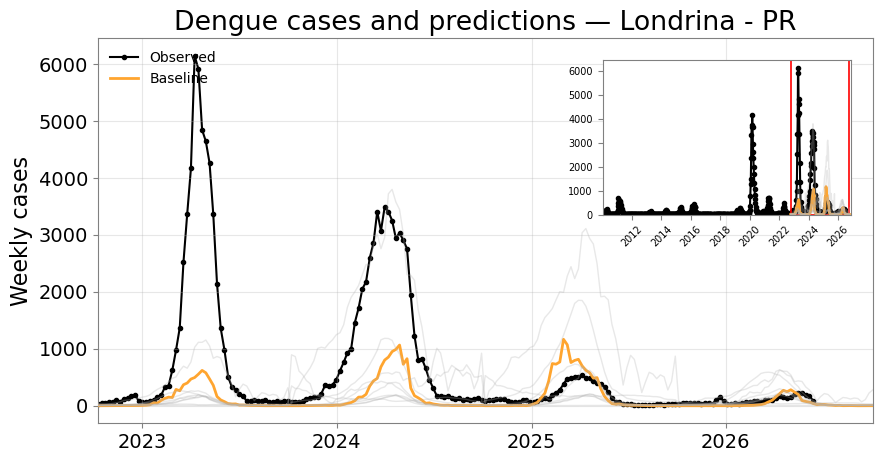

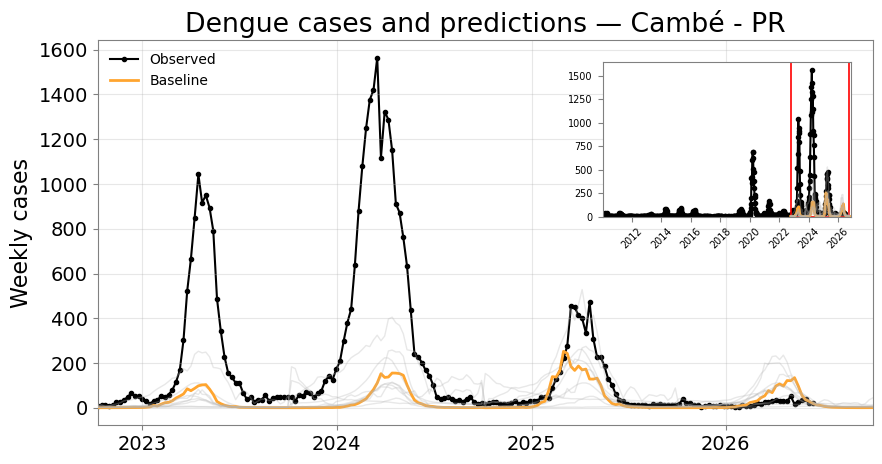

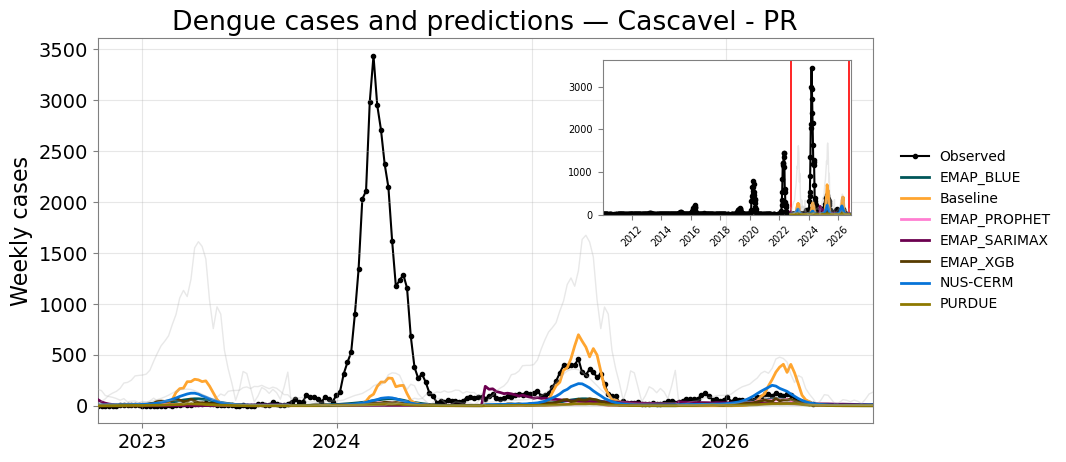

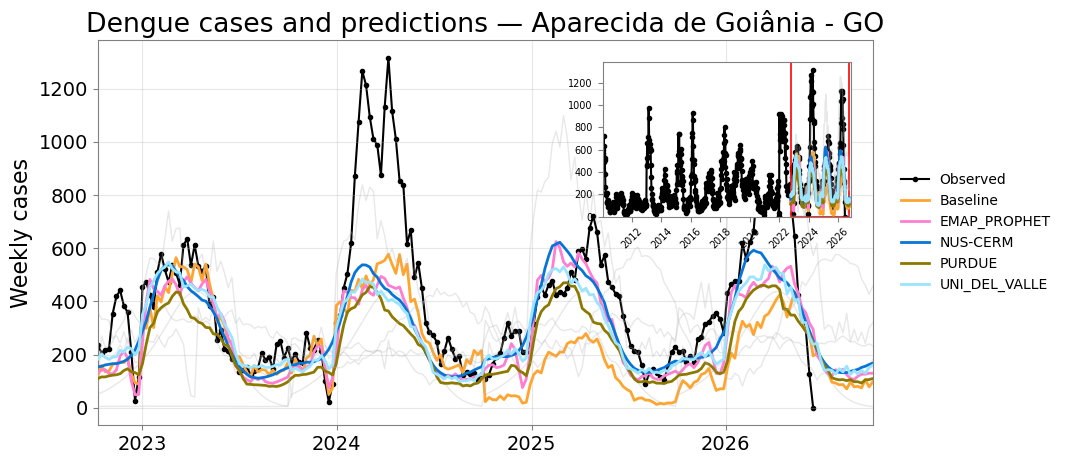

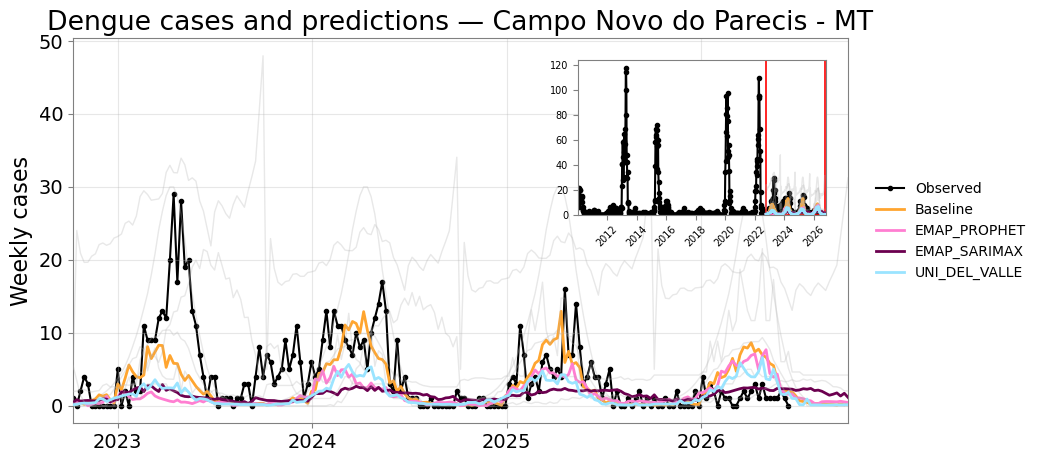

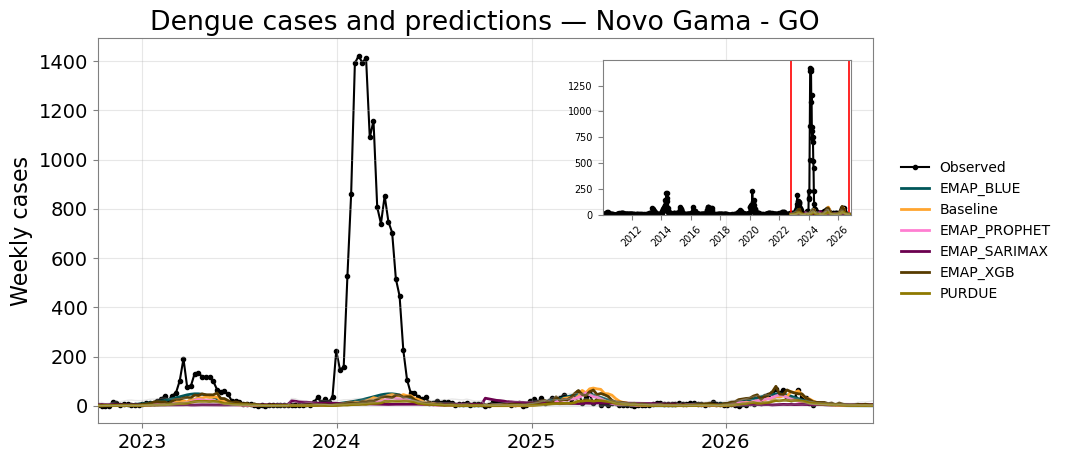

In [22]:
zoom_start = pd.to_datetime(Week(2022,41).startdate())
zoom_end = pd.to_datetime(Week(2026,40).startdate())


for geocode in df_preds.adm_2.unique(): 
    gname = df_summary.loc[df_summary.adm_2 == geocode]['adm_2_name'].values[0]
    plot_zoom_city(
        geocode,
        df_dengue,
        df_preds,
        df_summary,
        gname,
        color_palette,
        zoom_start,
        zoom_end,
        model_base="EMAP_LSTM",
        figsize=(10, 5),
        savepath=f'figures/zoom_{geocode}_{challenge}.png'
        )

    plt.show()
    plt.close()

### Rankplots: 

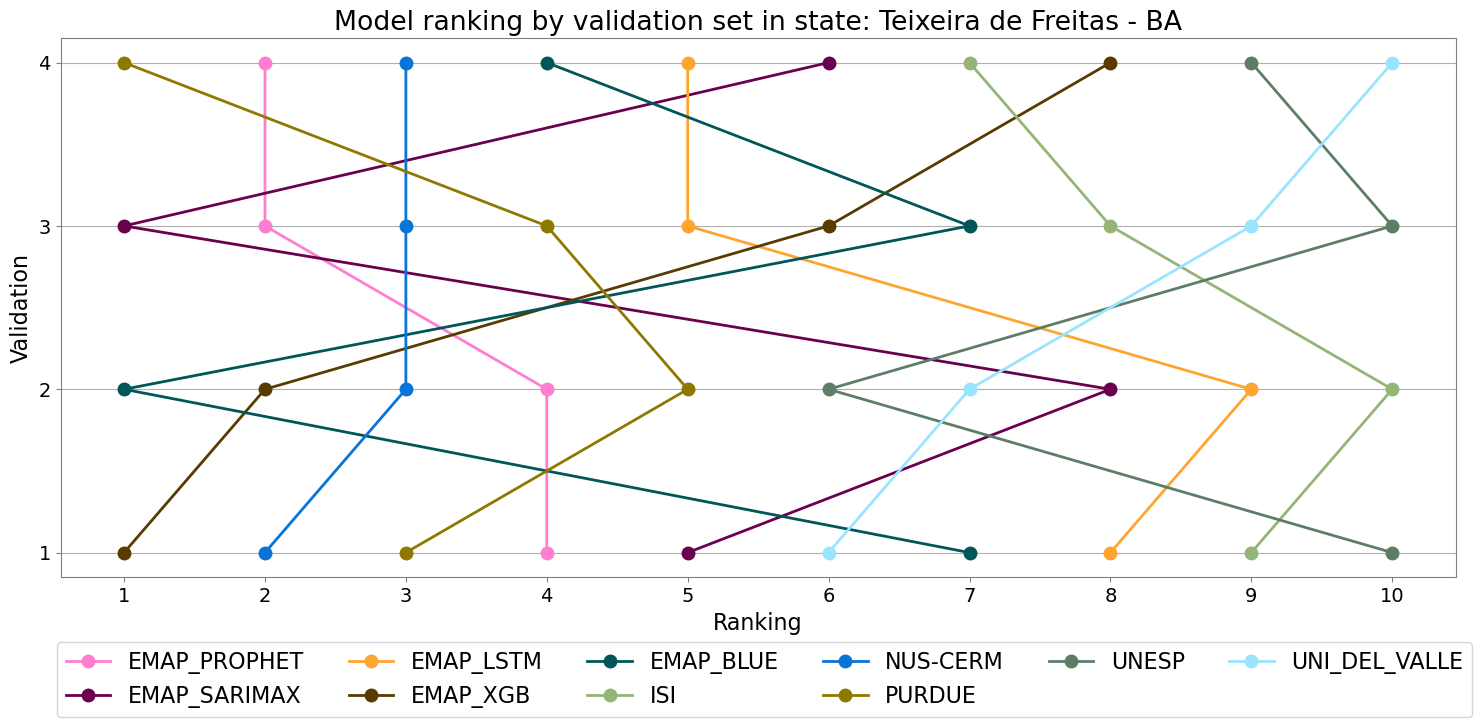

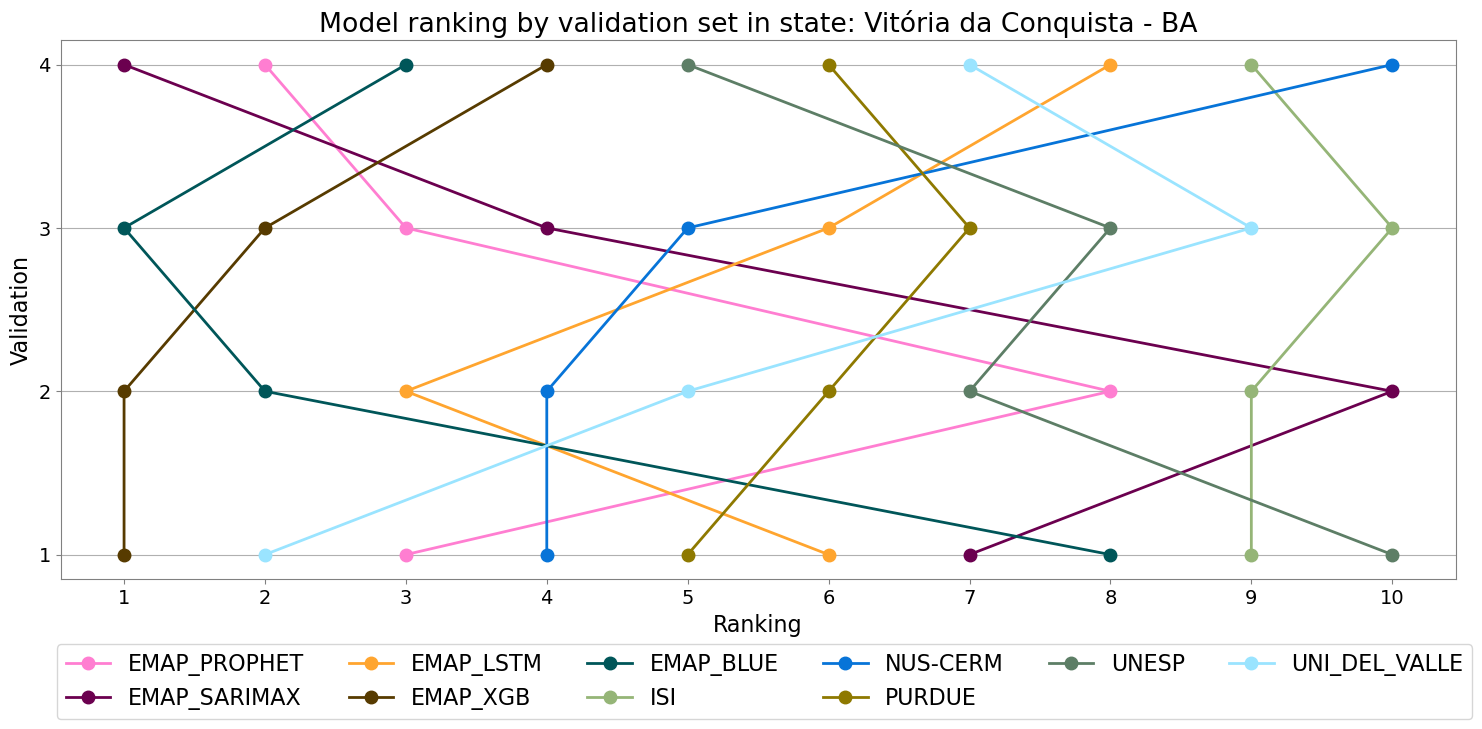

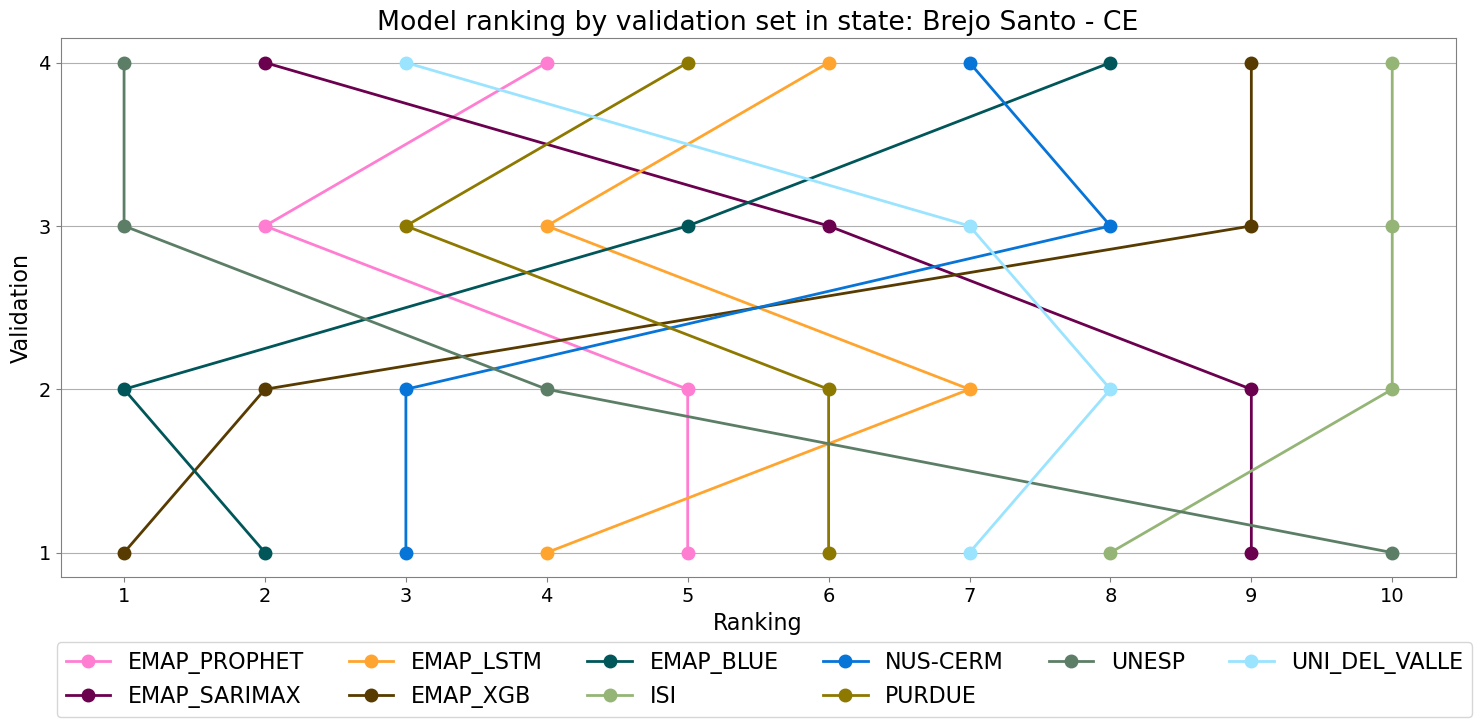

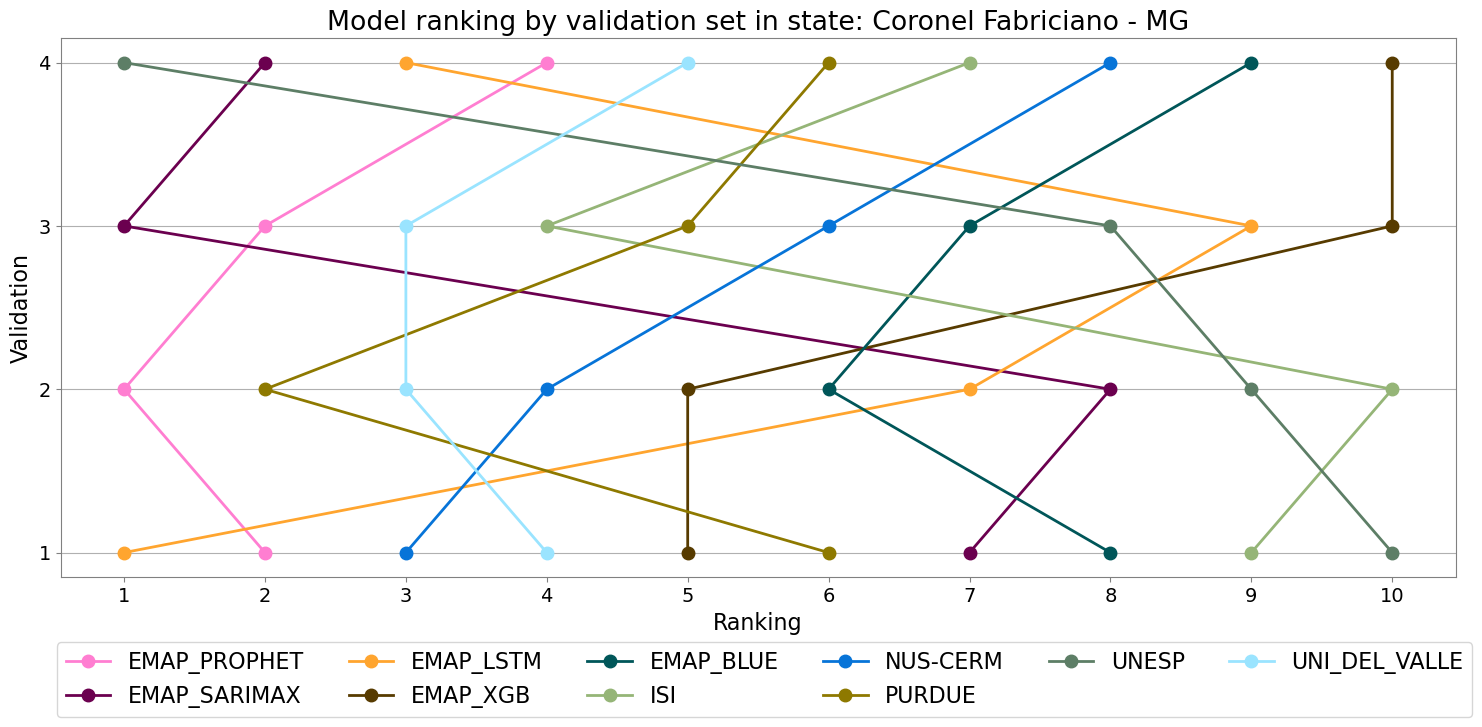

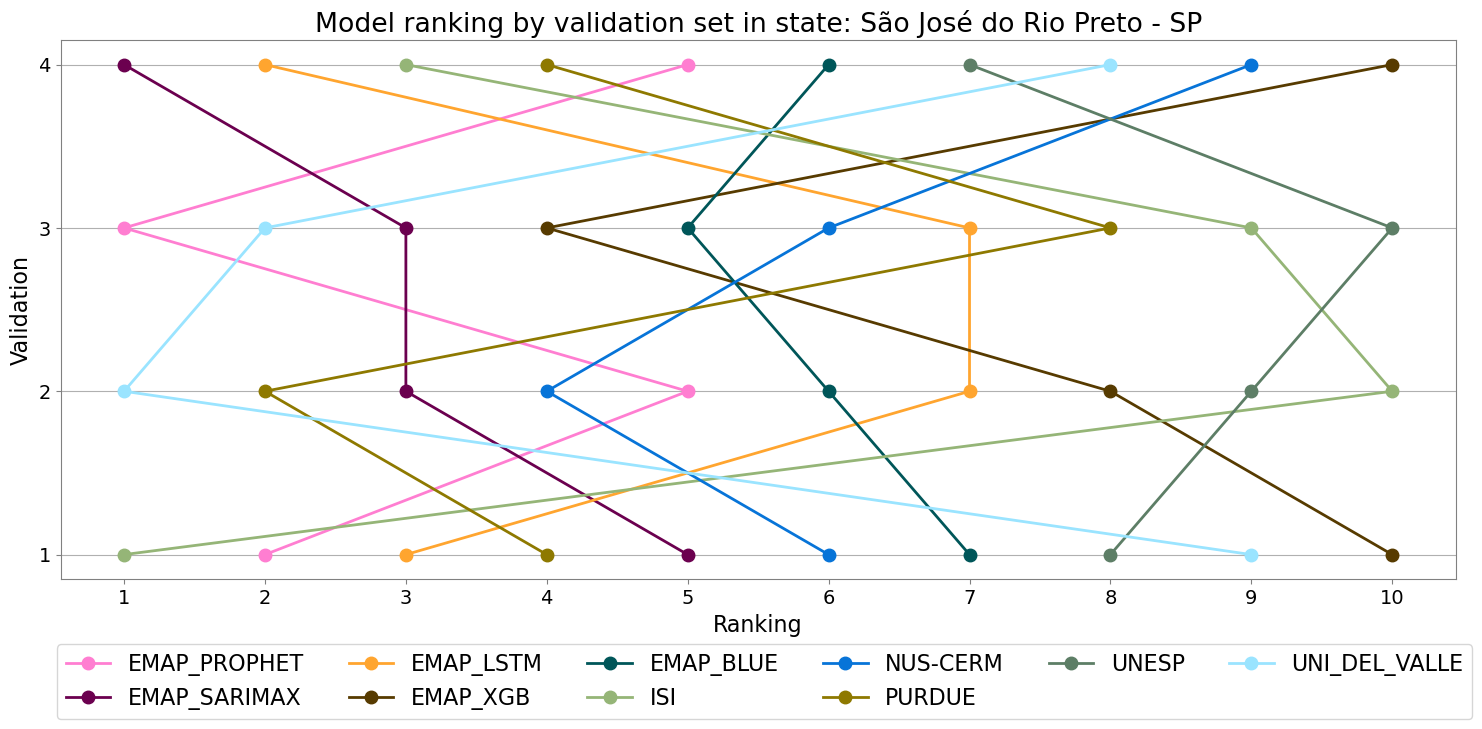

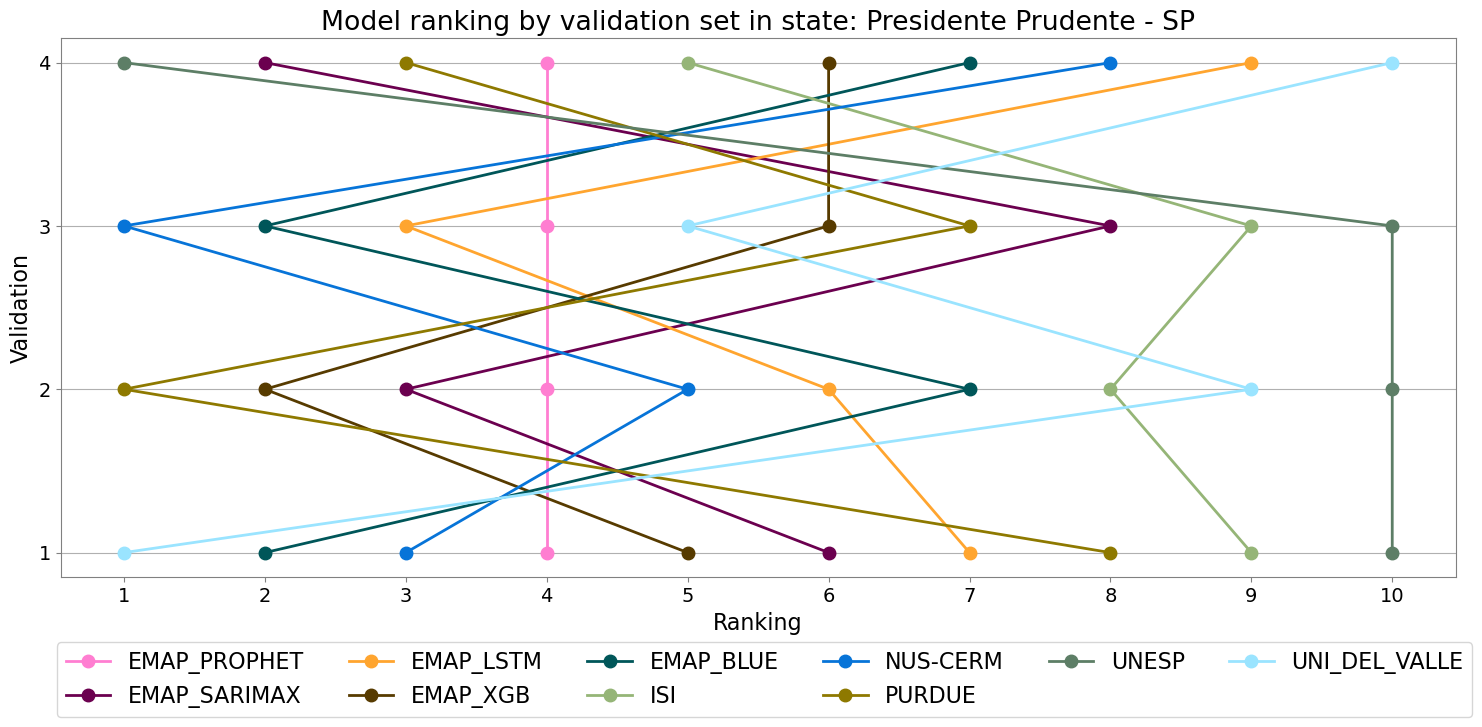

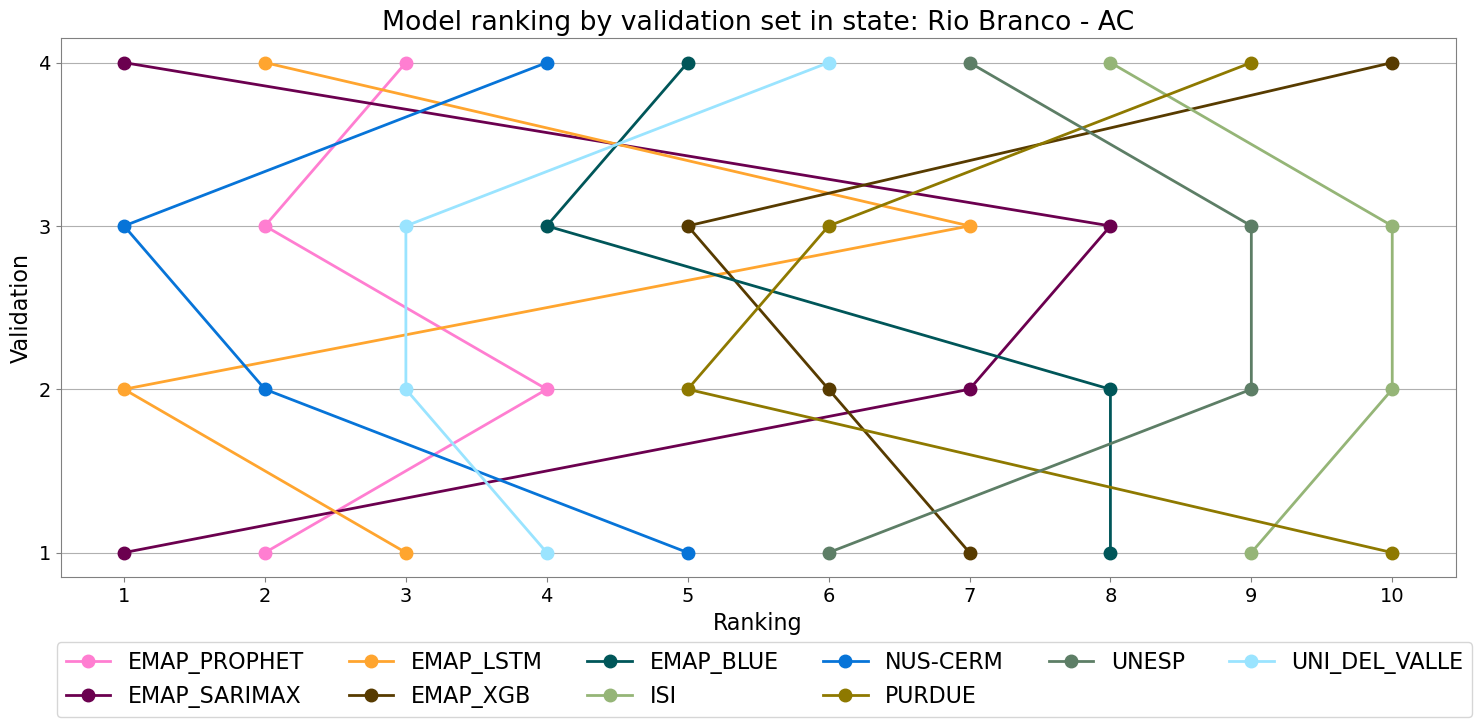

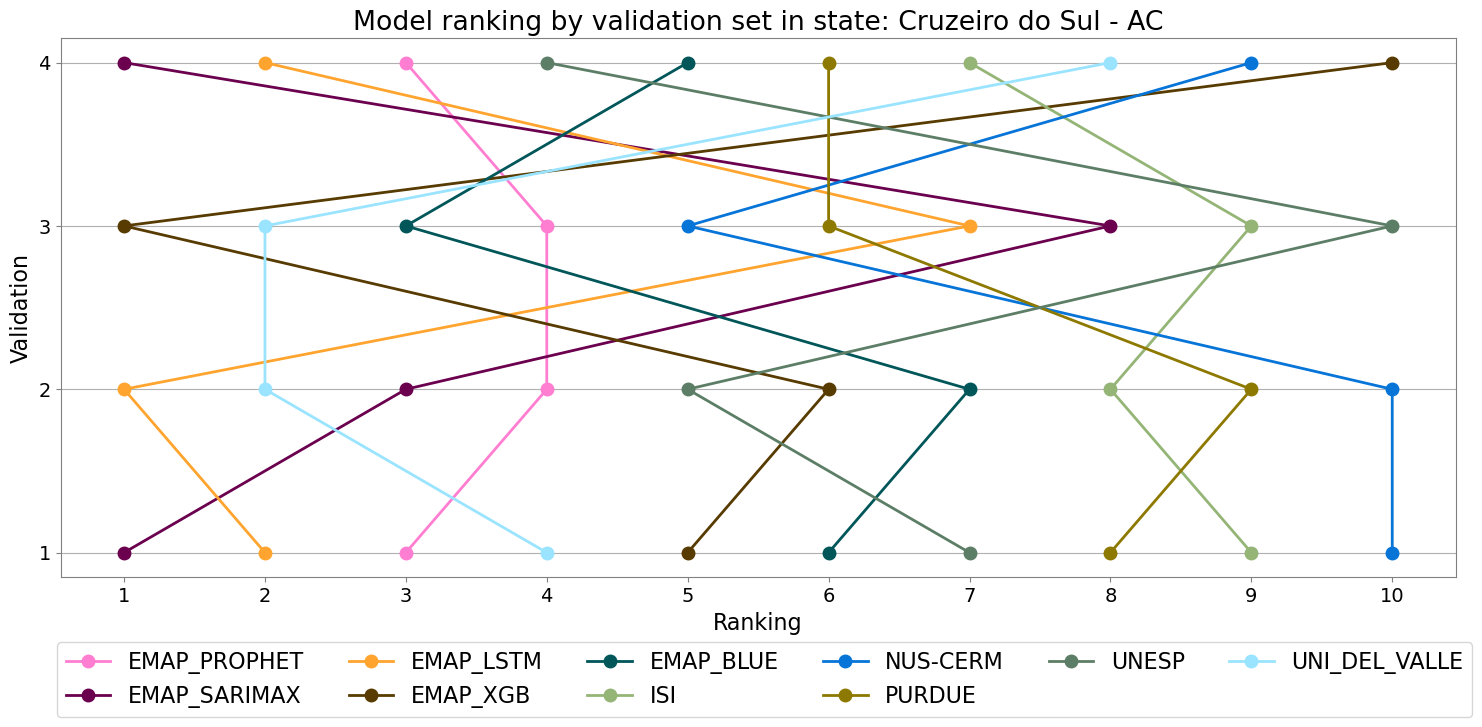

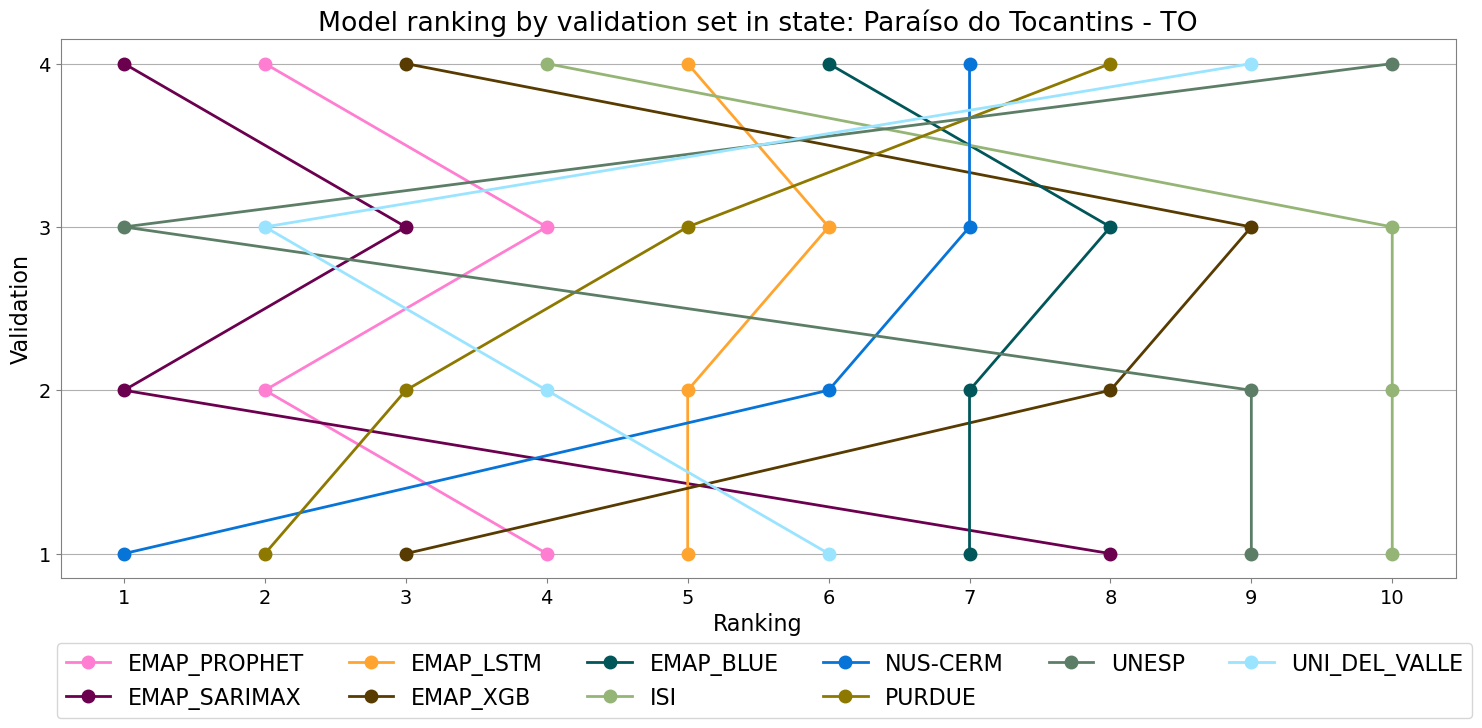

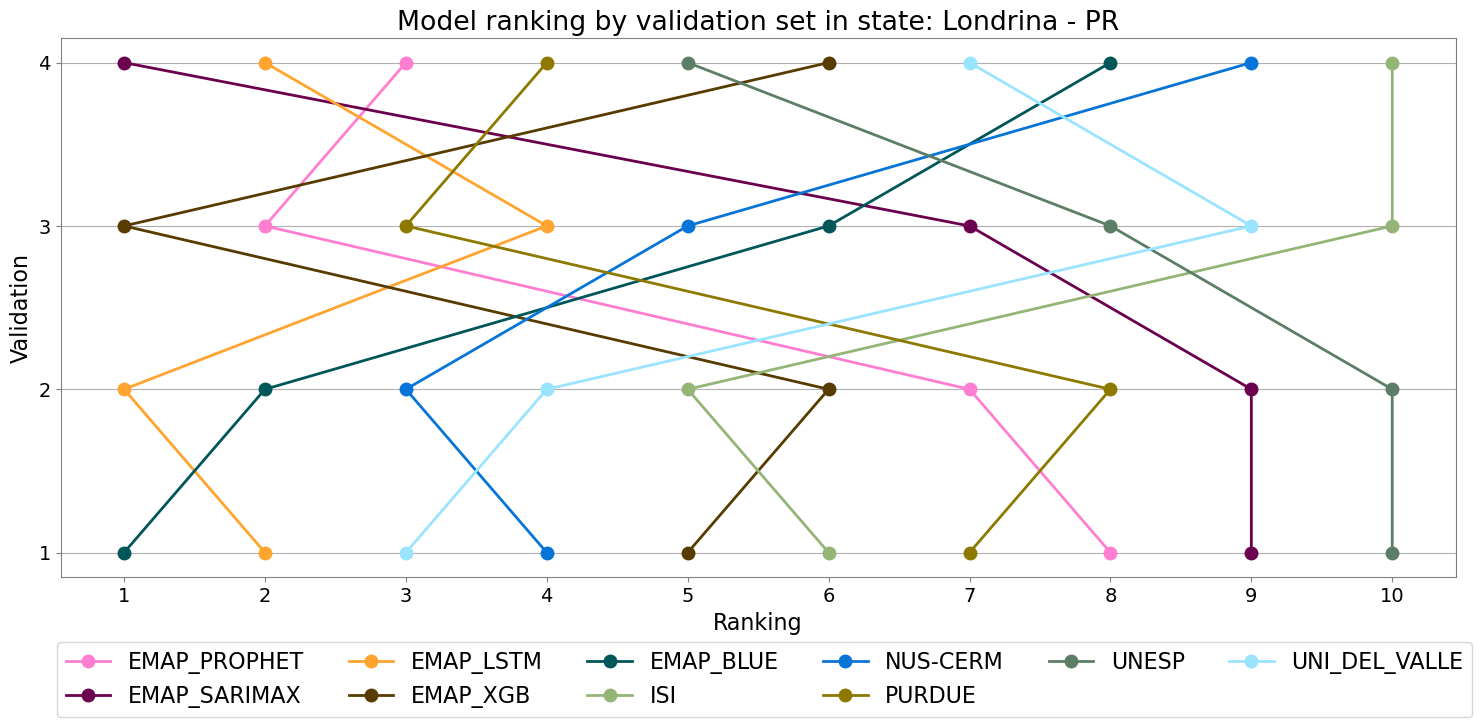

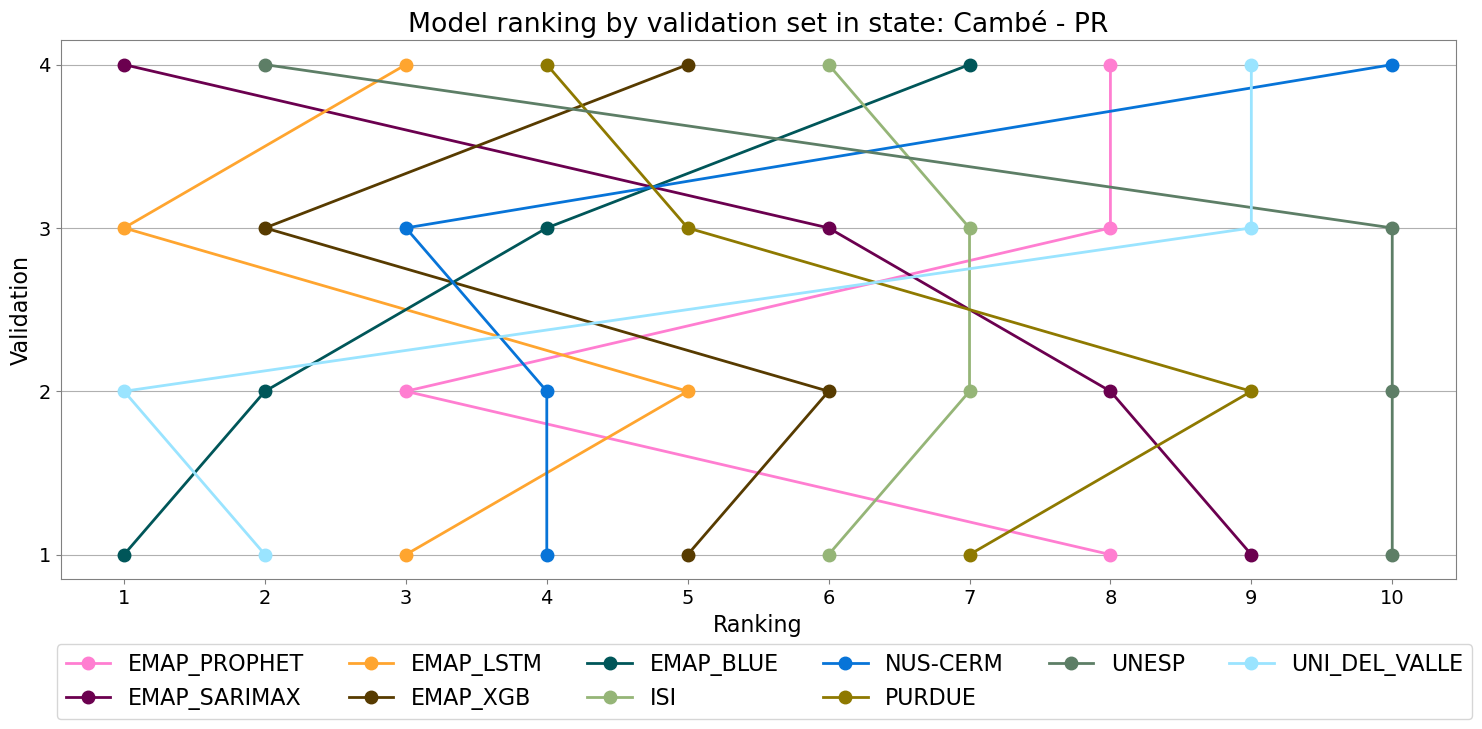

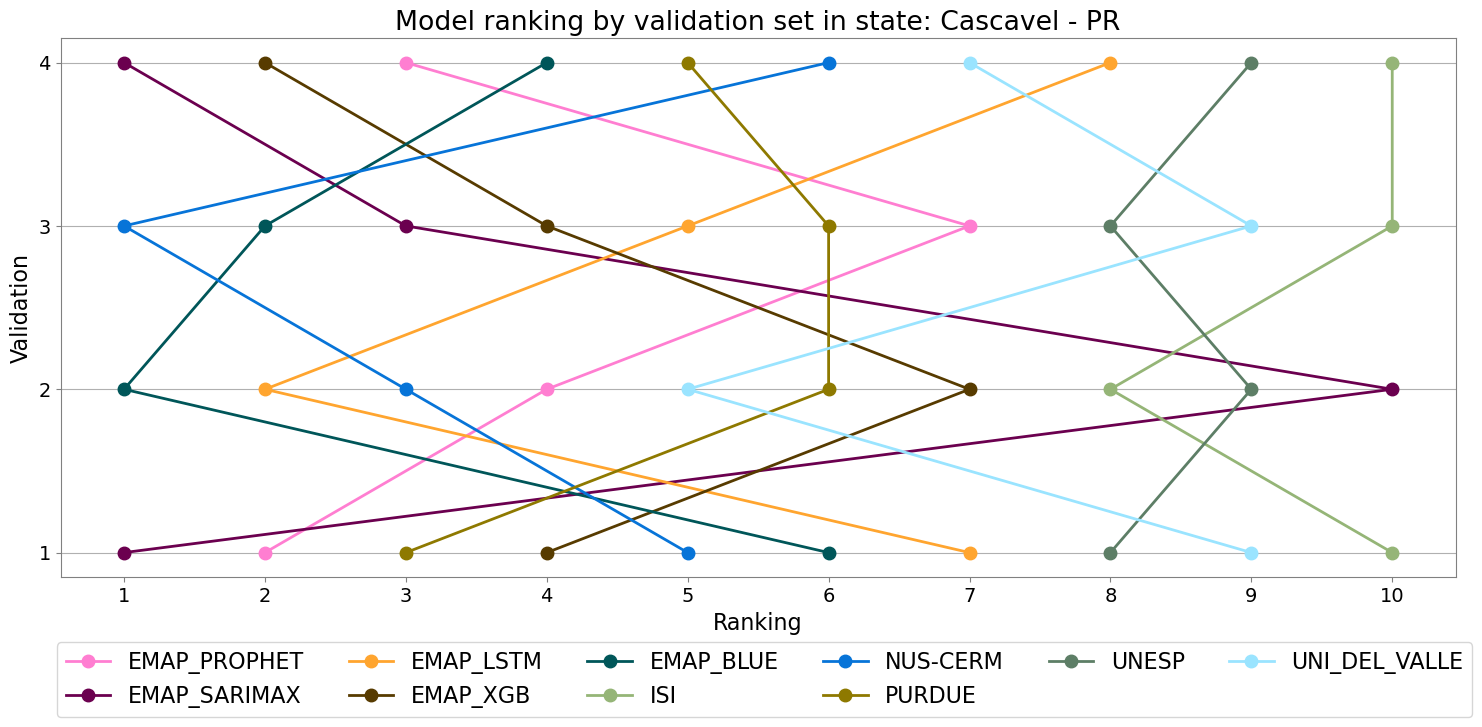

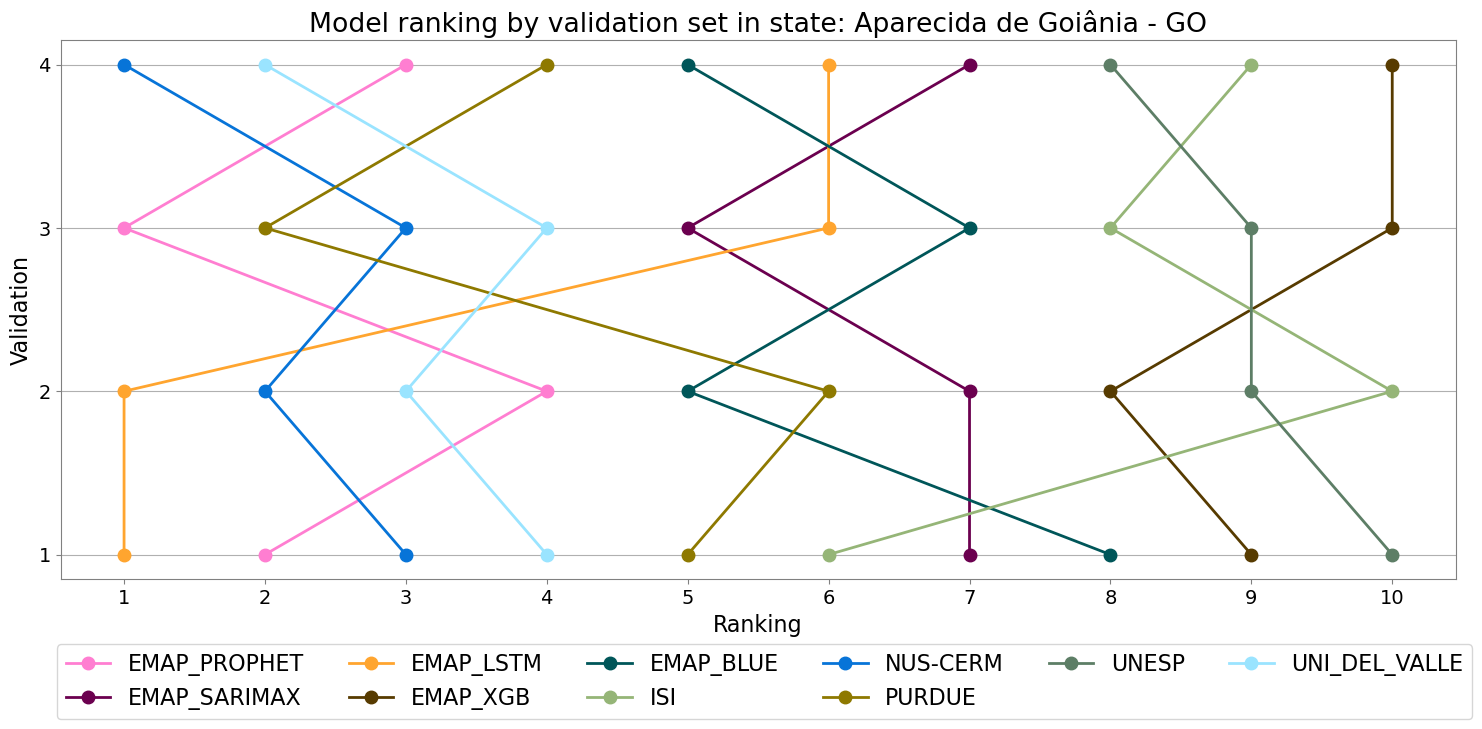

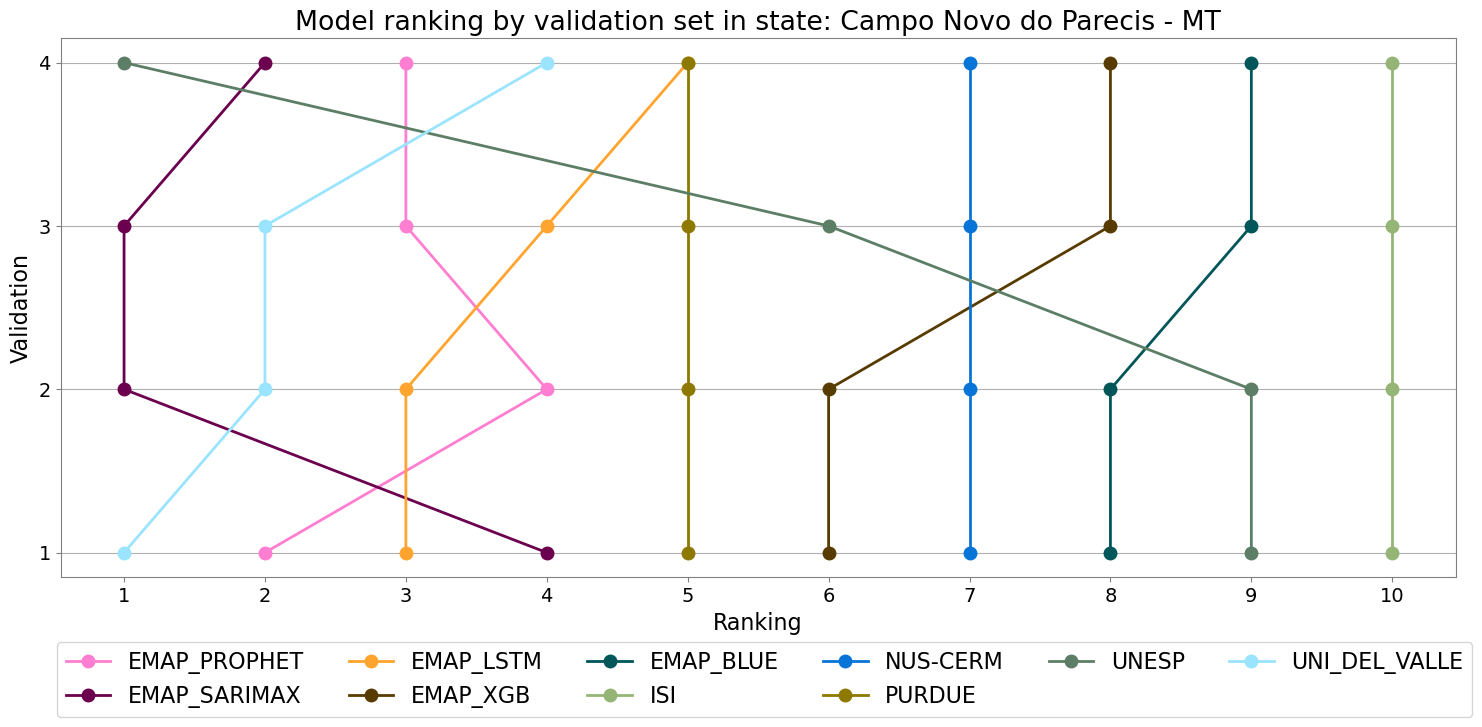

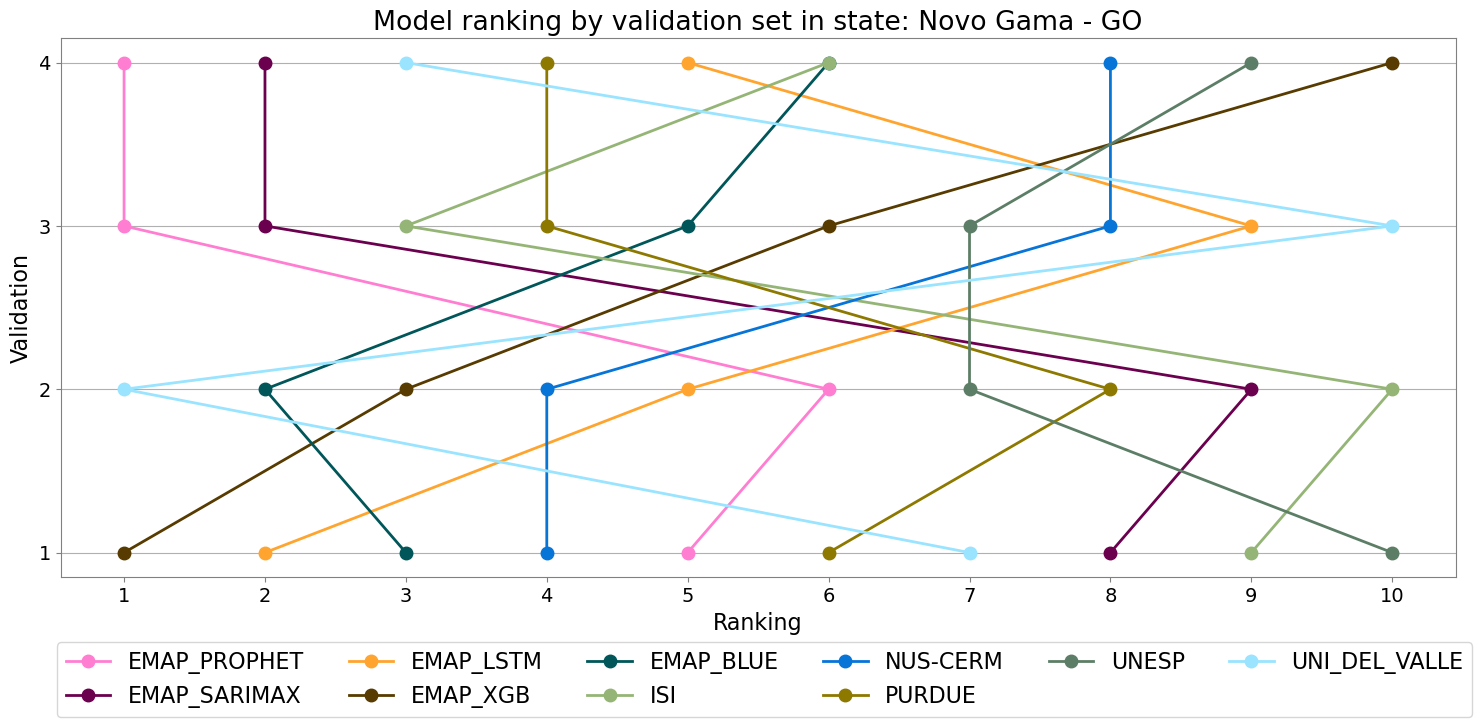

In [23]:
for geocode in df_preds.adm_2.unique(): 

    gname = df_summary.loc[df_summary.adm_2 == geocode]['adm_2_name'].values[0]

    plot_rankplot(
        df=df_rank,
        colors=color_palette,
        x_col="rank",
        x_label="Ranking",
        title="Model ranking by validation set",
        region=geocode,
        x_ticks=np.arange(1, 11),
        x_lim=None,
            ncols_legend=6,
            bbox_to_anchor=(1.02, -0.1), 
            challenge = challenge,
    region_col = 'adm_2',
    region_name = gname    )


### Comp distributions - max cases, peak cases and peak height:

In [24]:
df_true_params = pd.read_csv(f'data/parameters_{challenge}.csv.gz')

df_true_params.head()

,adm_2,validation,peak_week,total_cases,peak_height,peak_height_model,t_ini
0,2302503,1,27.926306,1778,123,91.615536,5
1,2302503,2,25.416013,2682,281,205.732148,9
2,2302503,3,29.753307,92,9,4.000470,1
3,2302503,4,31.436001,105,11,6.078803,4
4,2933307,1,27.563940,1028,55,47.937934,2


In [25]:
df_pars = pd.read_csv(f'predictions/new_metrics_{challenge}_new.csv.gz')
df_pars['model'] = df_pars['model'].replace(rename_models)
df_pars.head()

,model,validation,adm_2,season_total_p25,season_total_p50,season_total_p975,season_peak_p25,season_peak_p50,season_peak_p975,r0_dist_p25,...,r0_dist_p975,pico_dist_p25,pico_dist_p50,pico_dist_p975,t_ini_dist_p25,t_ini_dist_p50,t_ini_dist_p975,max_c_dist_p25,max_c_dist_p50,max_c_dist_p975
0,EMAP_BLUE,2,2933307,733.909479,1885.217757,5779.345512,102.064520,424.618497,2774.845948,1.093611,...,2.483450,19.937389,26.636748,35.000000,1.0,1.0,22.050,26.576949,108.947387,737.993226
1,EMAP_BLUE,3,2933307,26.696225,663.509646,14658.005350,1.446443,35.322667,728.108614,1.155805,...,1.601317,25.994597,26.212592,26.849500,1.0,3.0,4.000,5.168774,35.858010,985.399530
2,EMAP_BLUE,4,2933307,28.478913,669.702784,12714.789369,1.542586,35.587938,626.672167,1.153066,...,1.613907,25.956333,26.295624,26.869531,1.0,3.0,4.525,1.366005,29.999773,518.939225
3,EMAP_LSTM,2,2933307,418.685033,1503.722946,6778.437599,63.409813,324.554007,3012.014323,1.061563,...,2.757746,12.042234,27.559206,35.000000,1.0,5.0,23.000,16.251780,87.164511,697.228118
4,EMAP_LSTM,3,2933307,16.006771,737.750230,42054.270271,3.011120,73.681697,3145.717538,1.195574,...,1.734411,22.242303,25.958029,28.205975,1.0,7.0,10.000,4.843071,47.411474,3534.781850


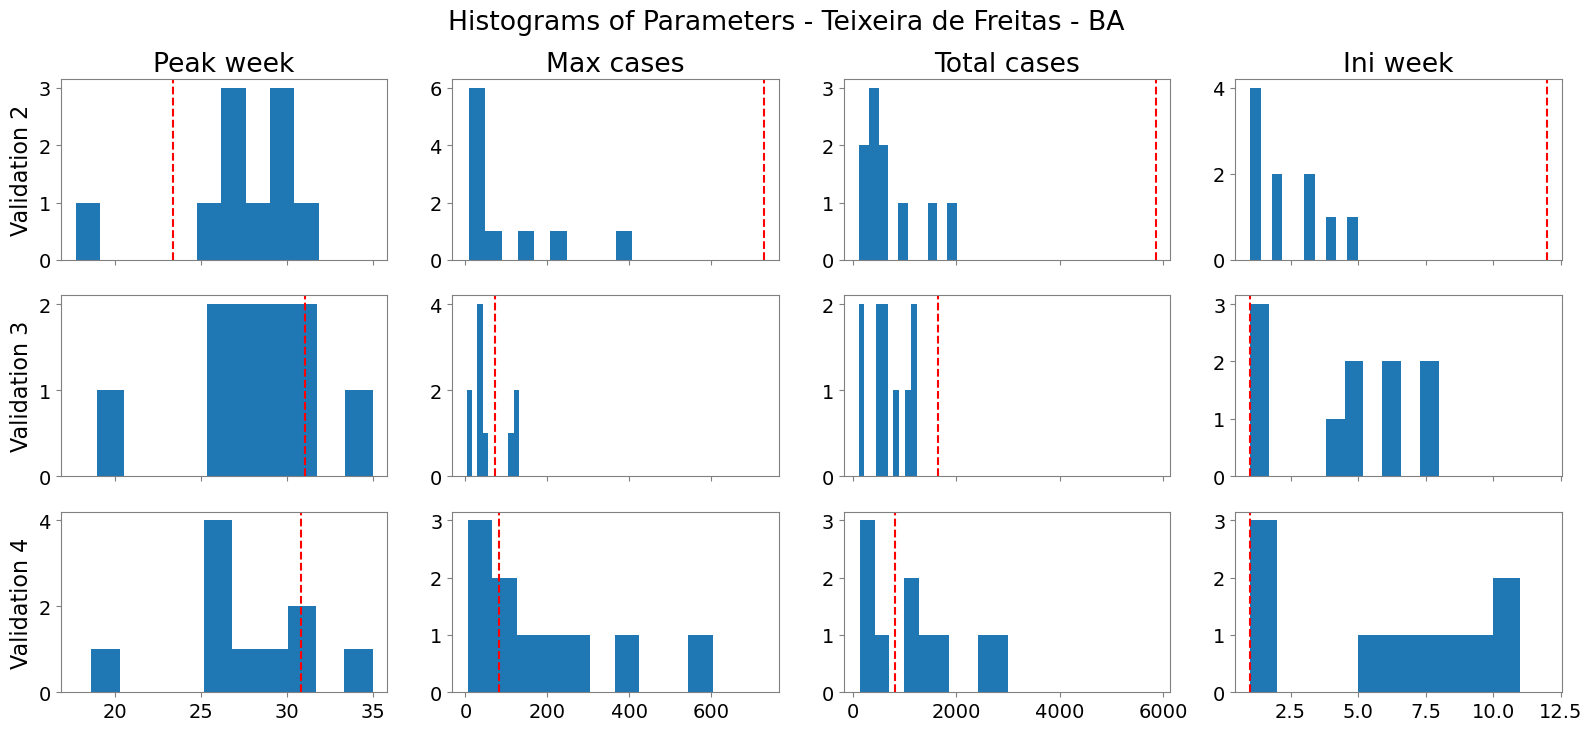

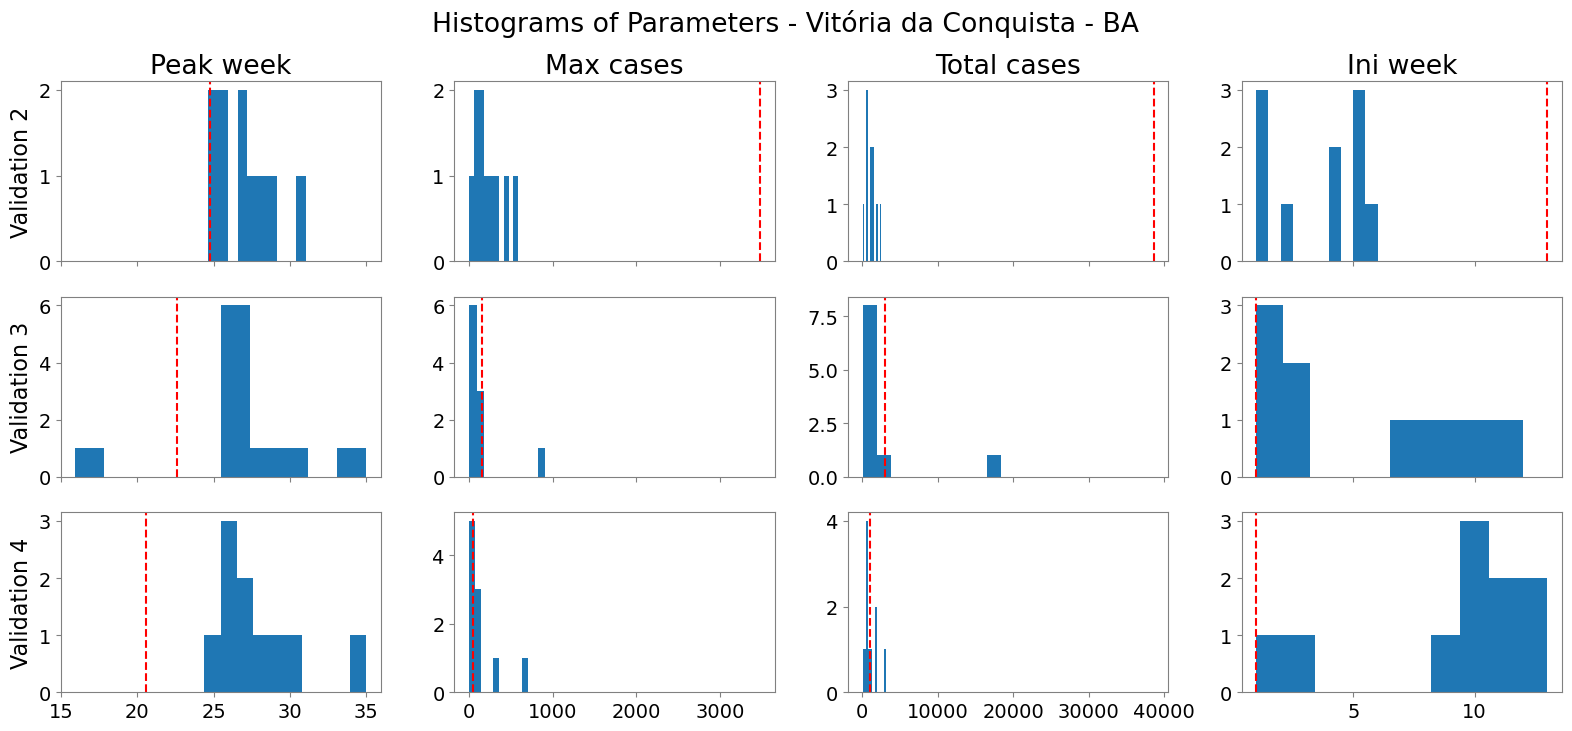

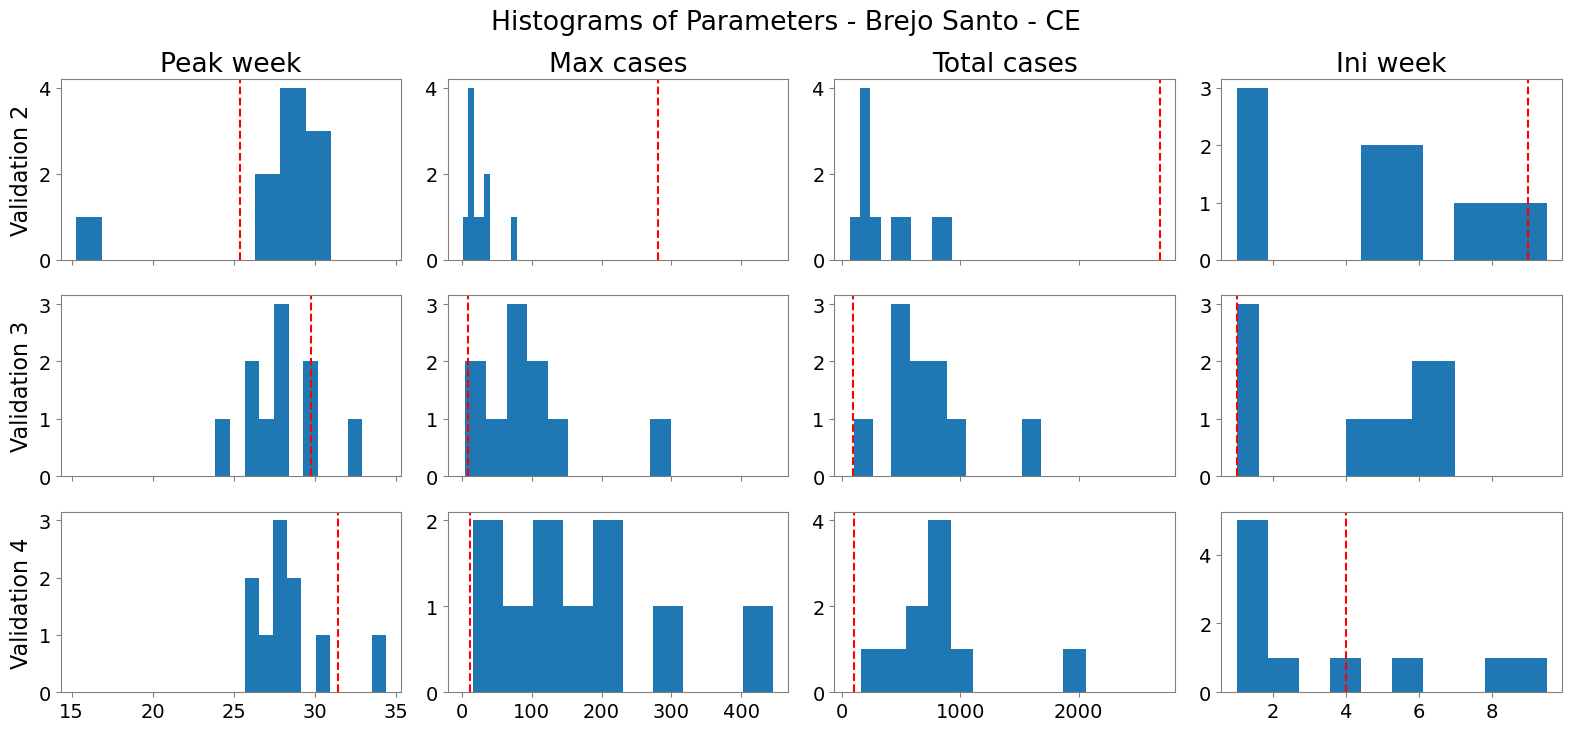

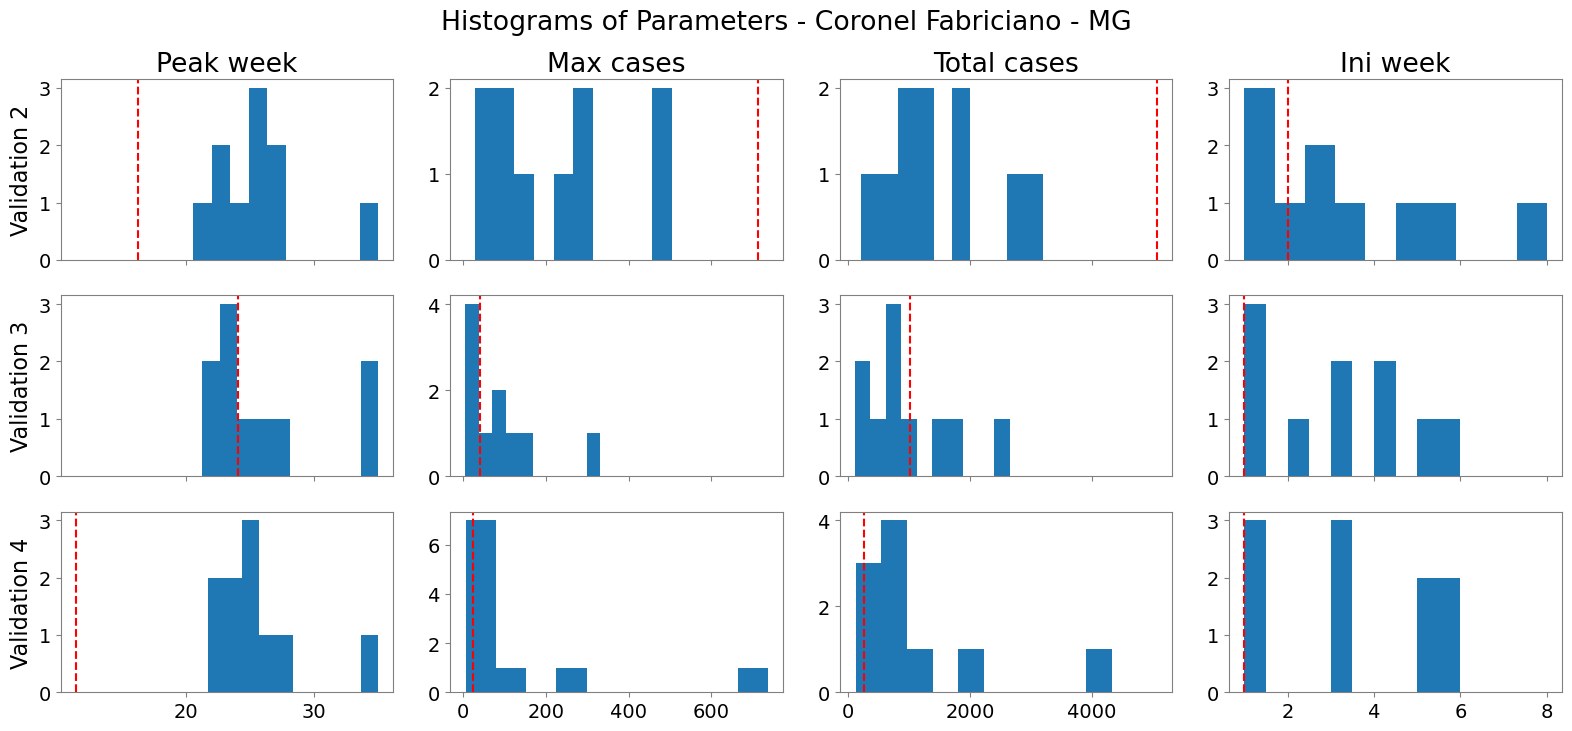

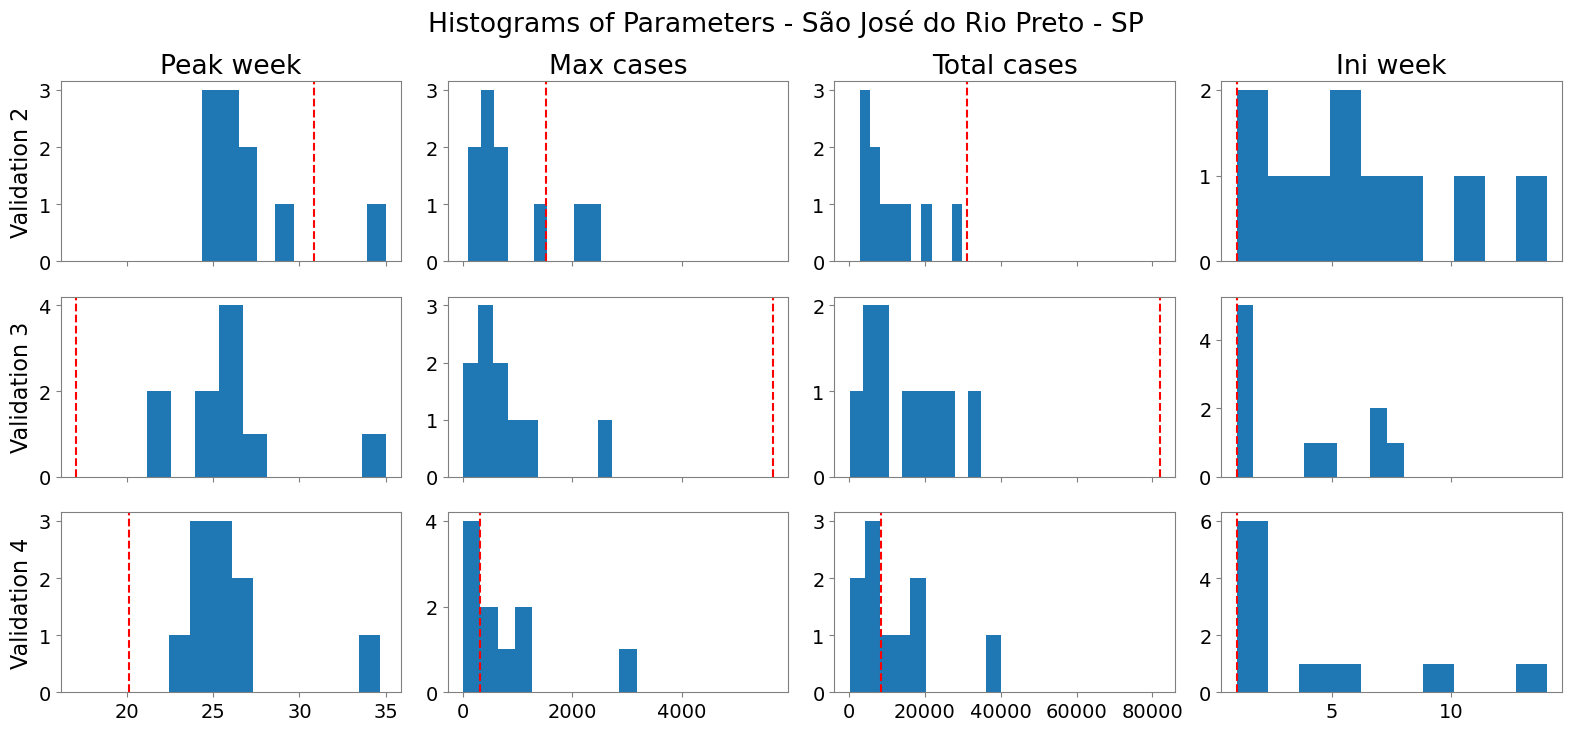

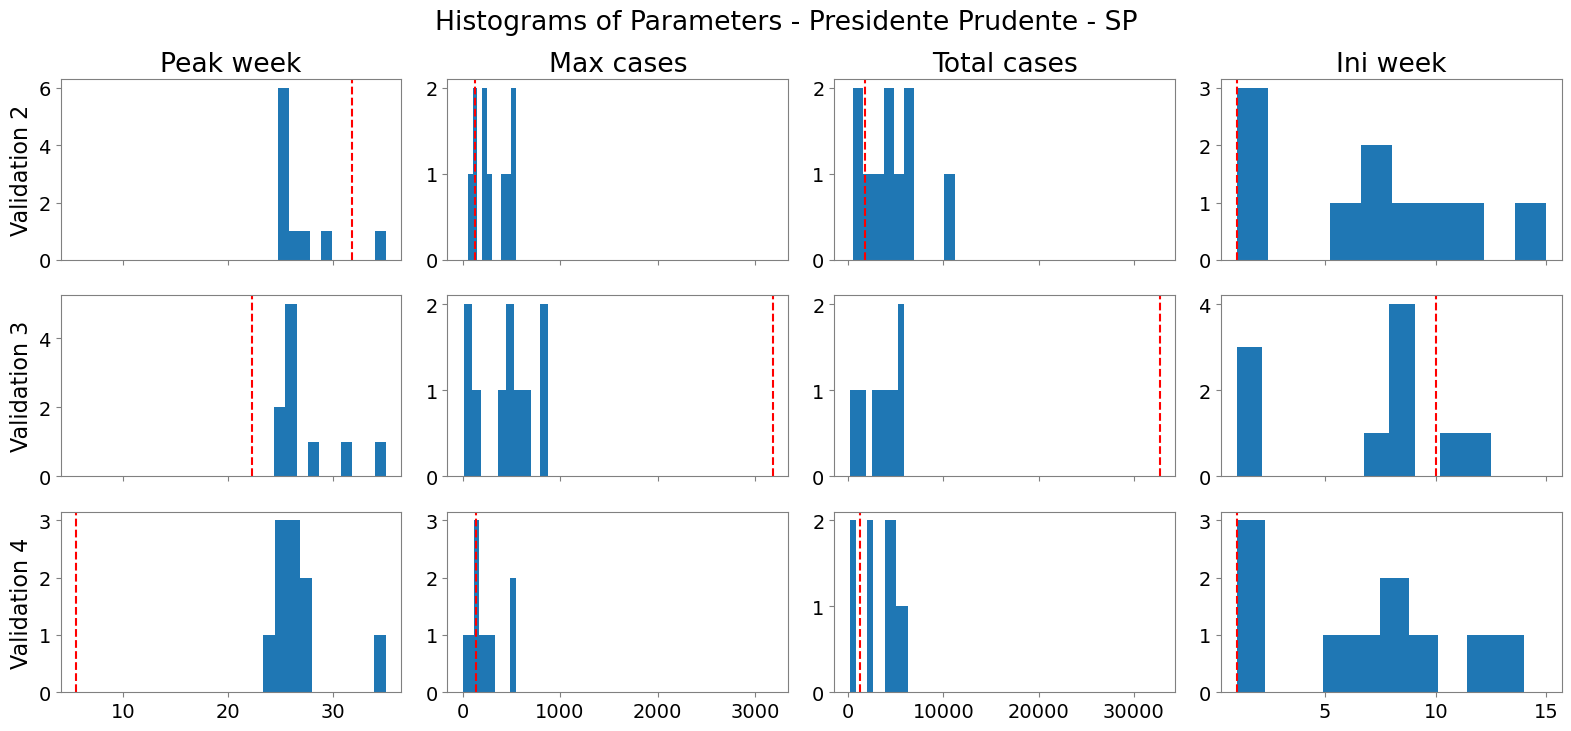

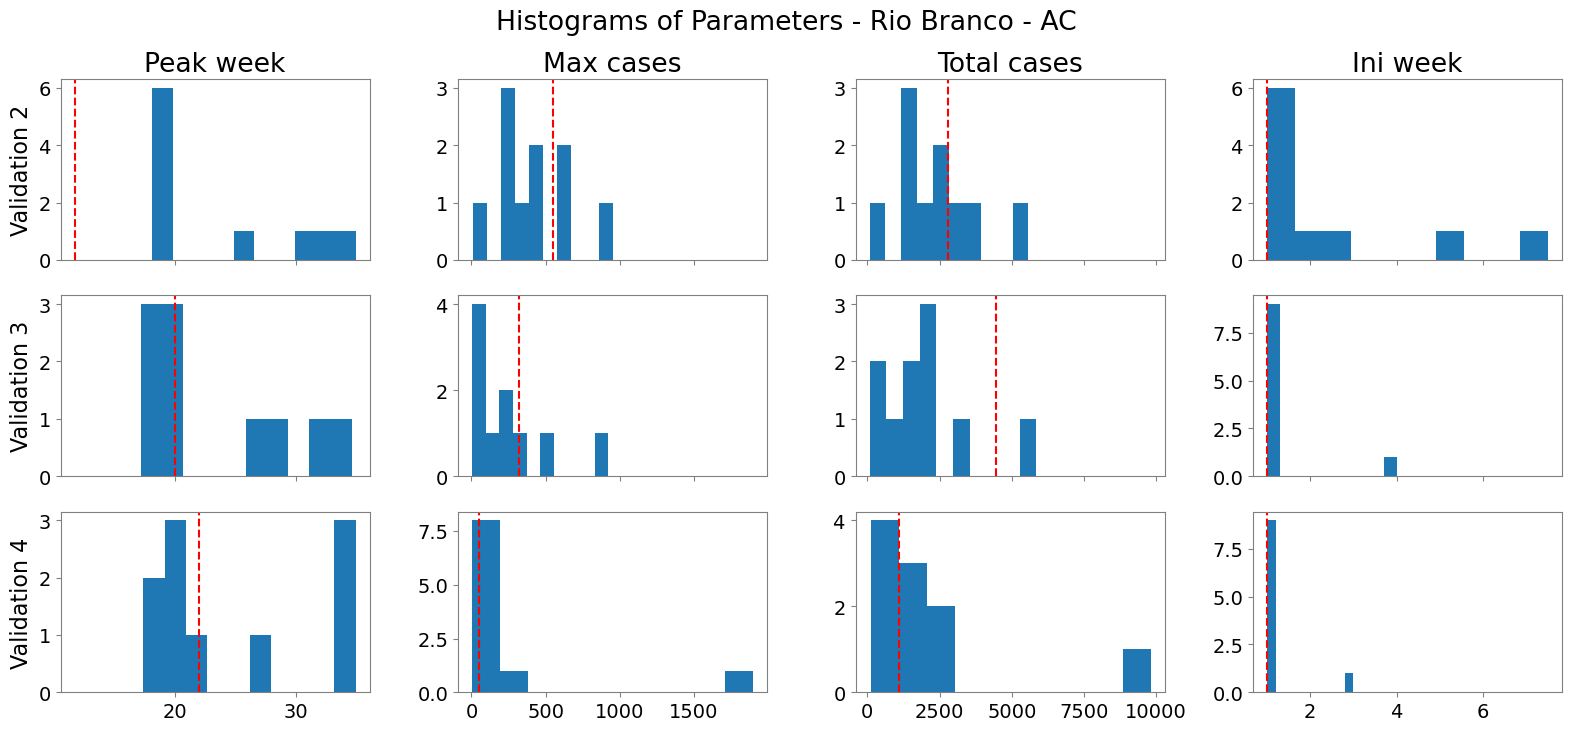

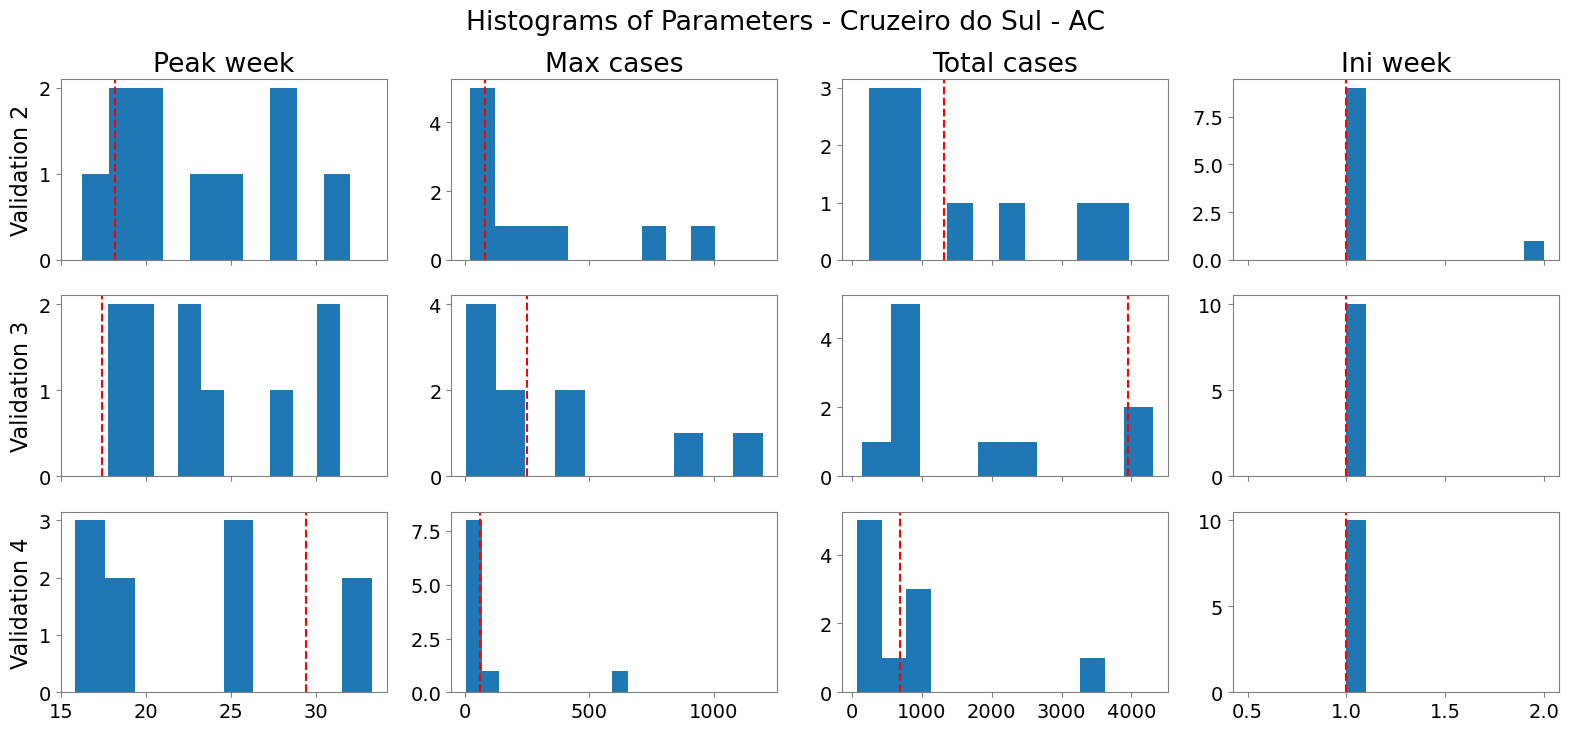

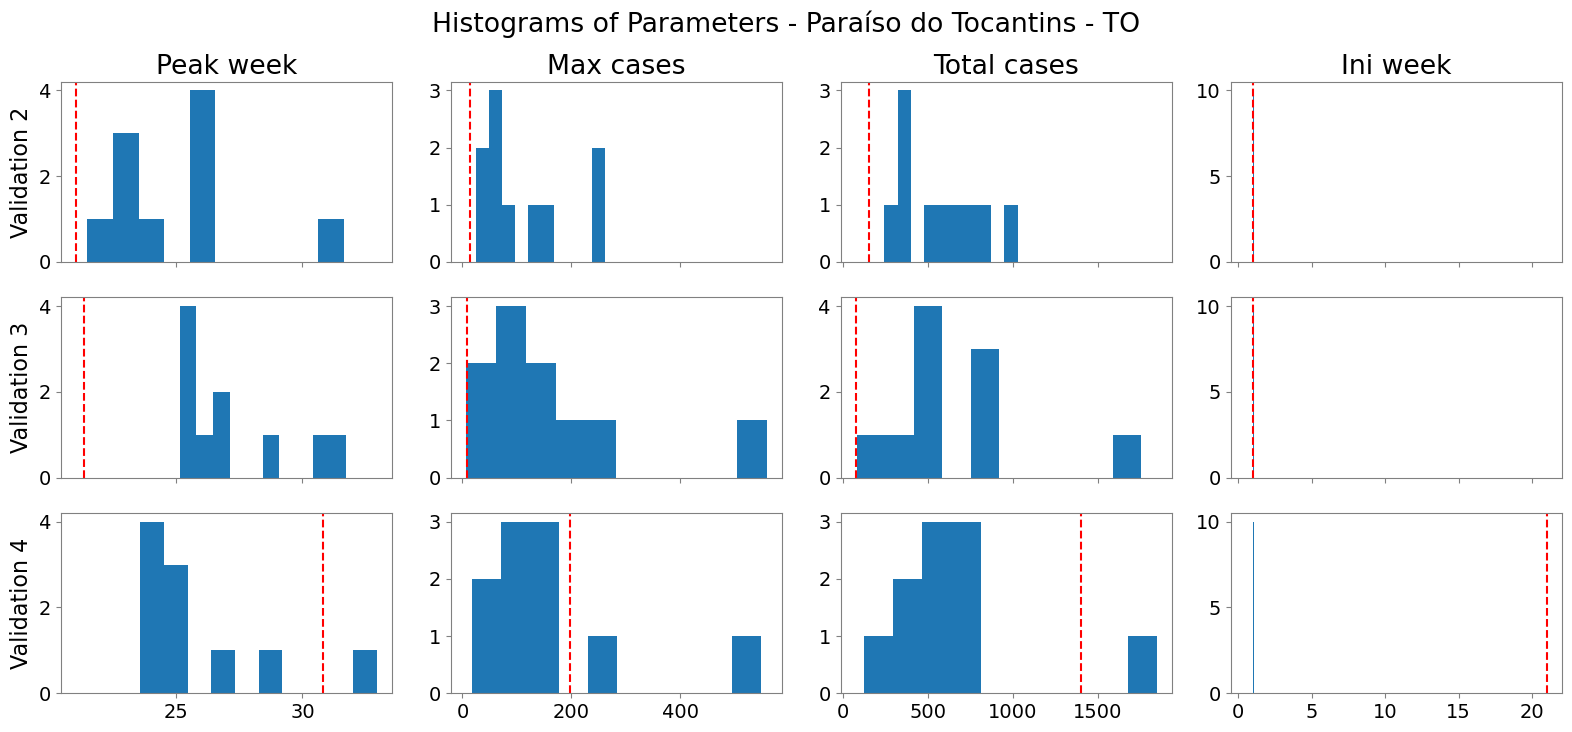

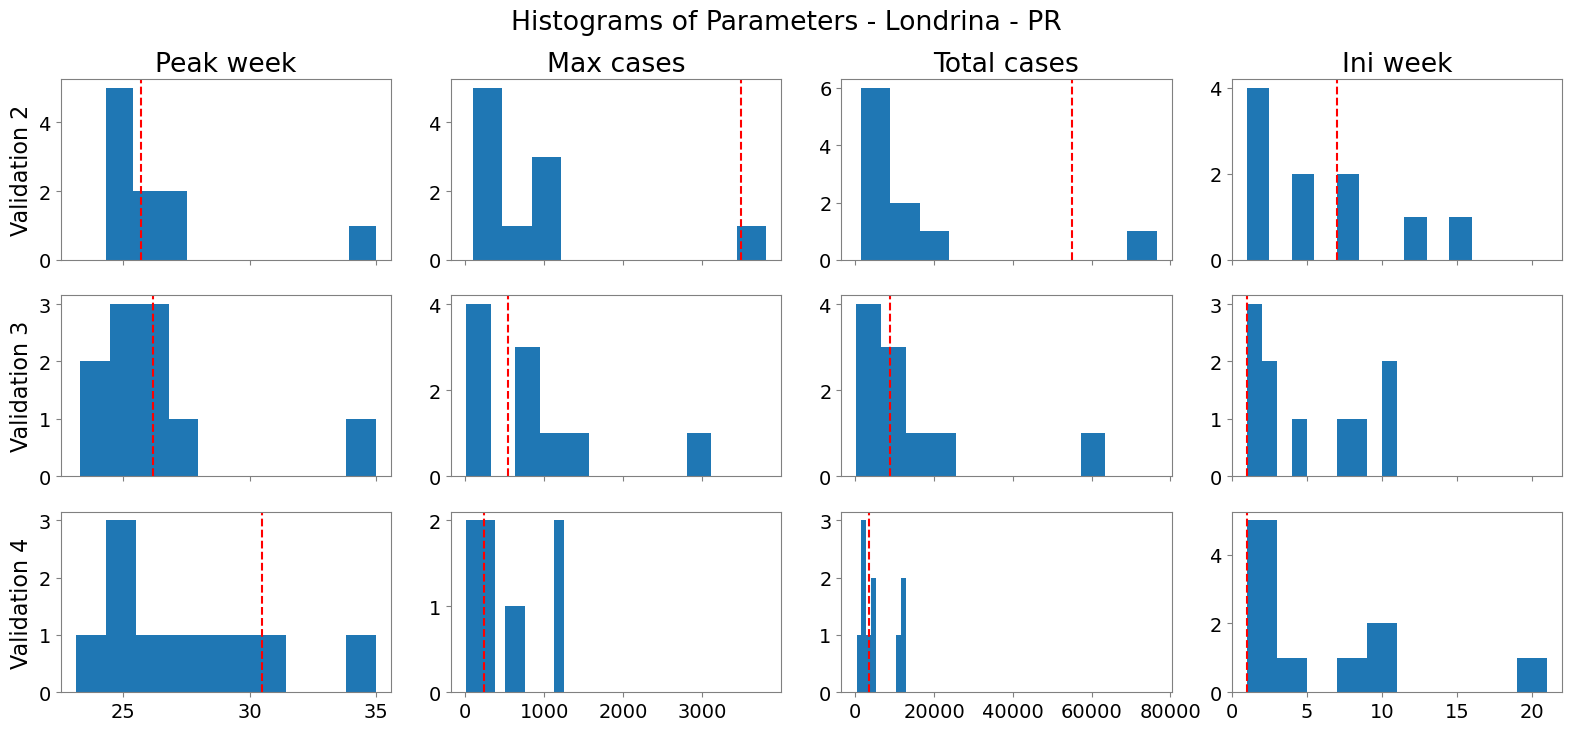

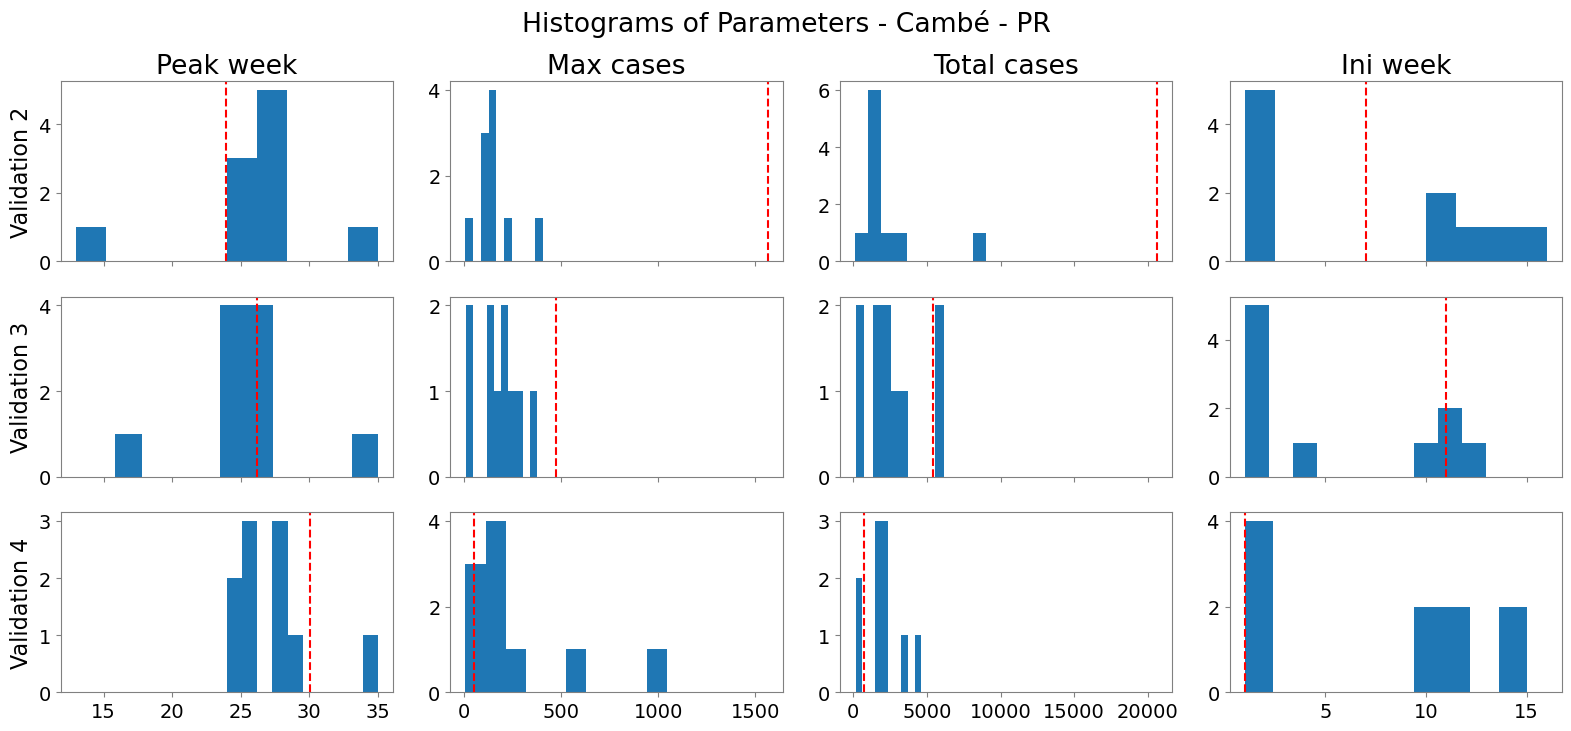

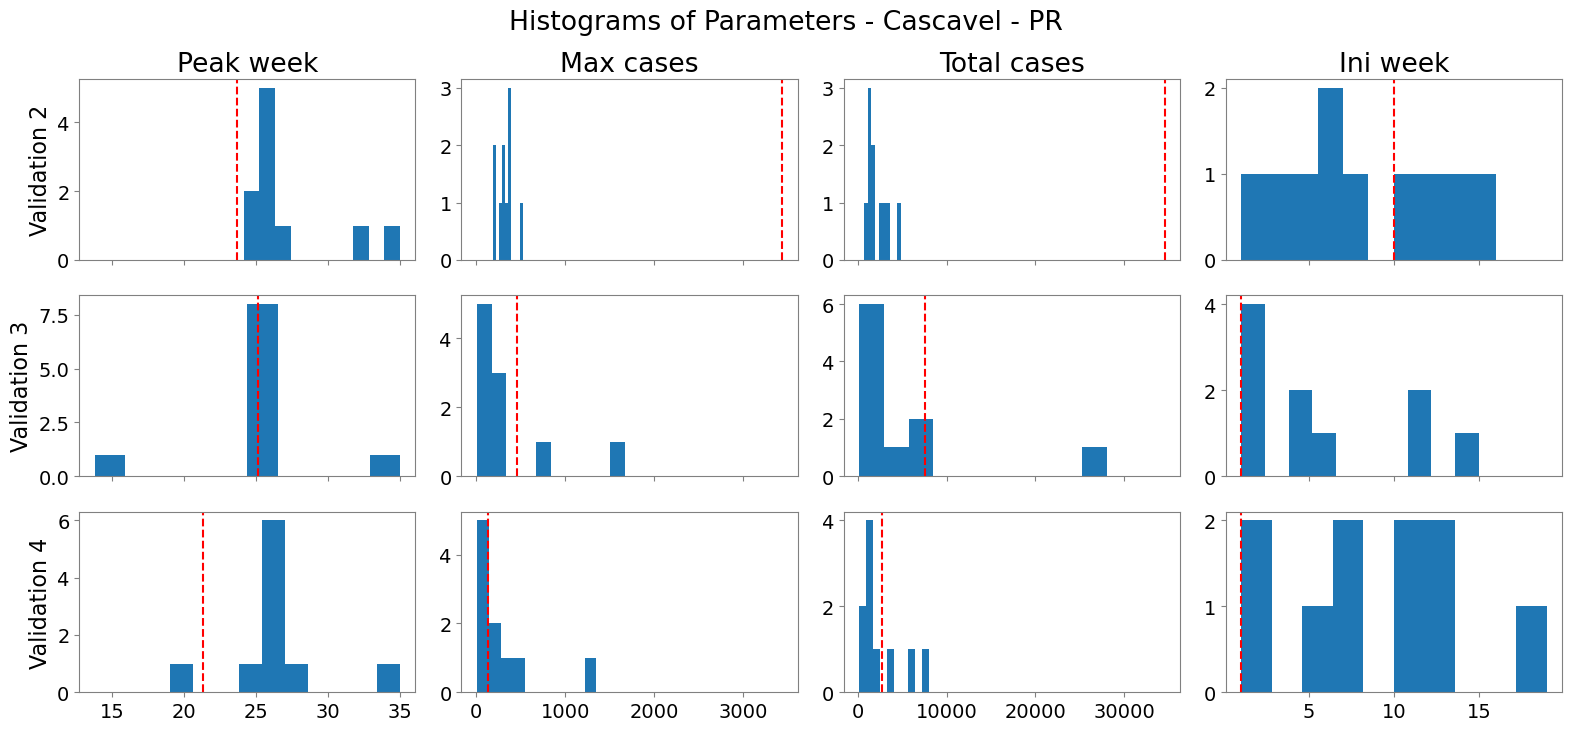

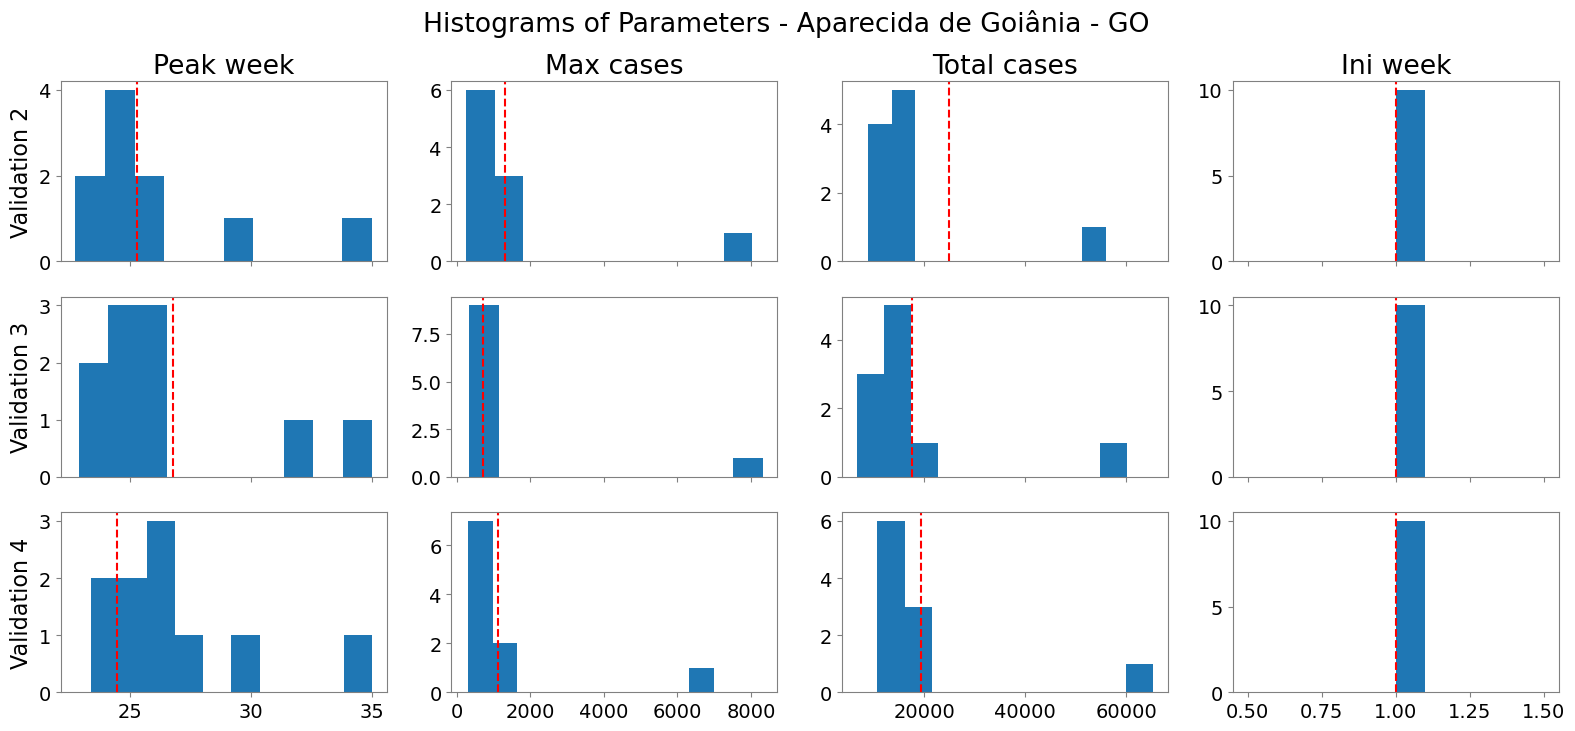

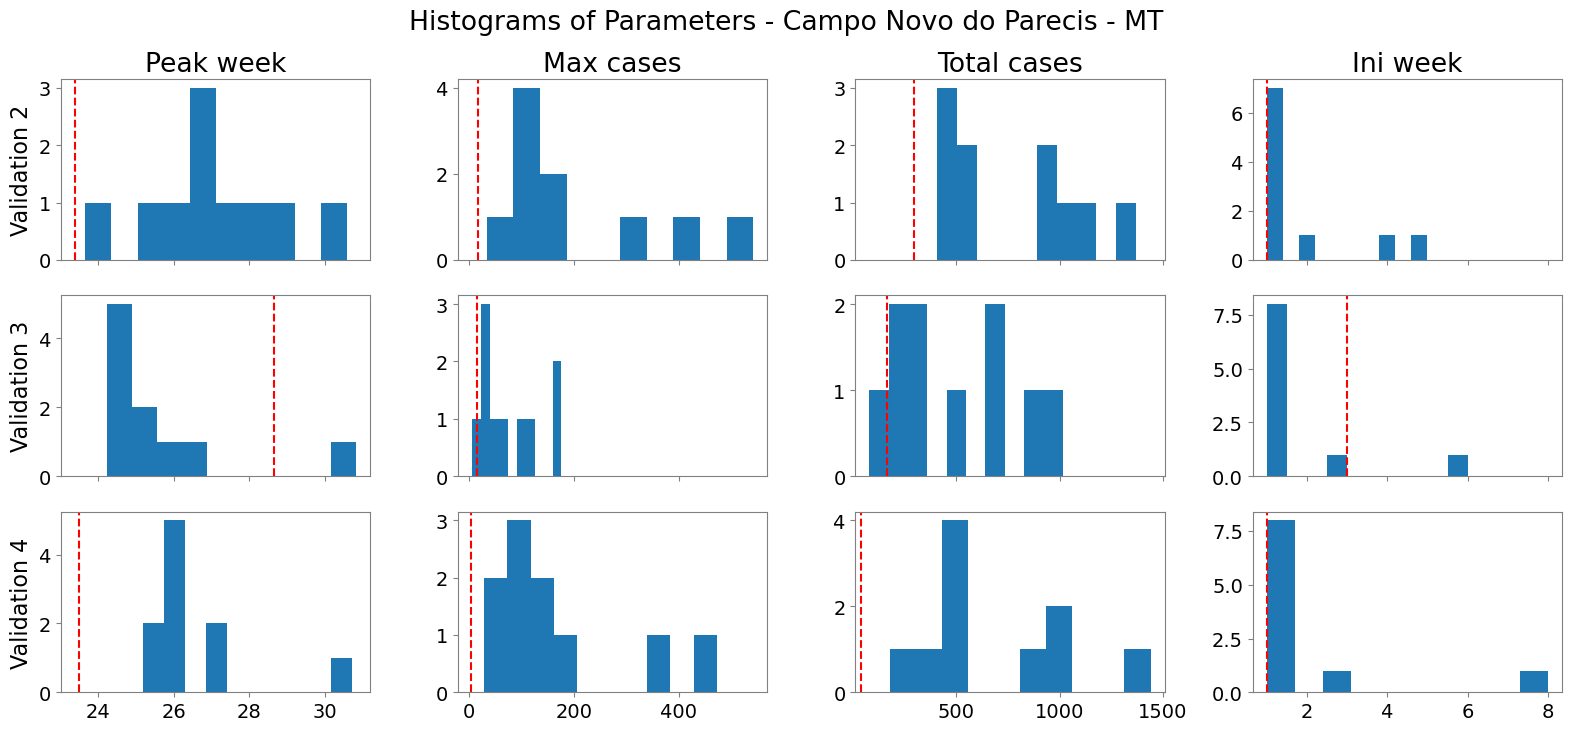

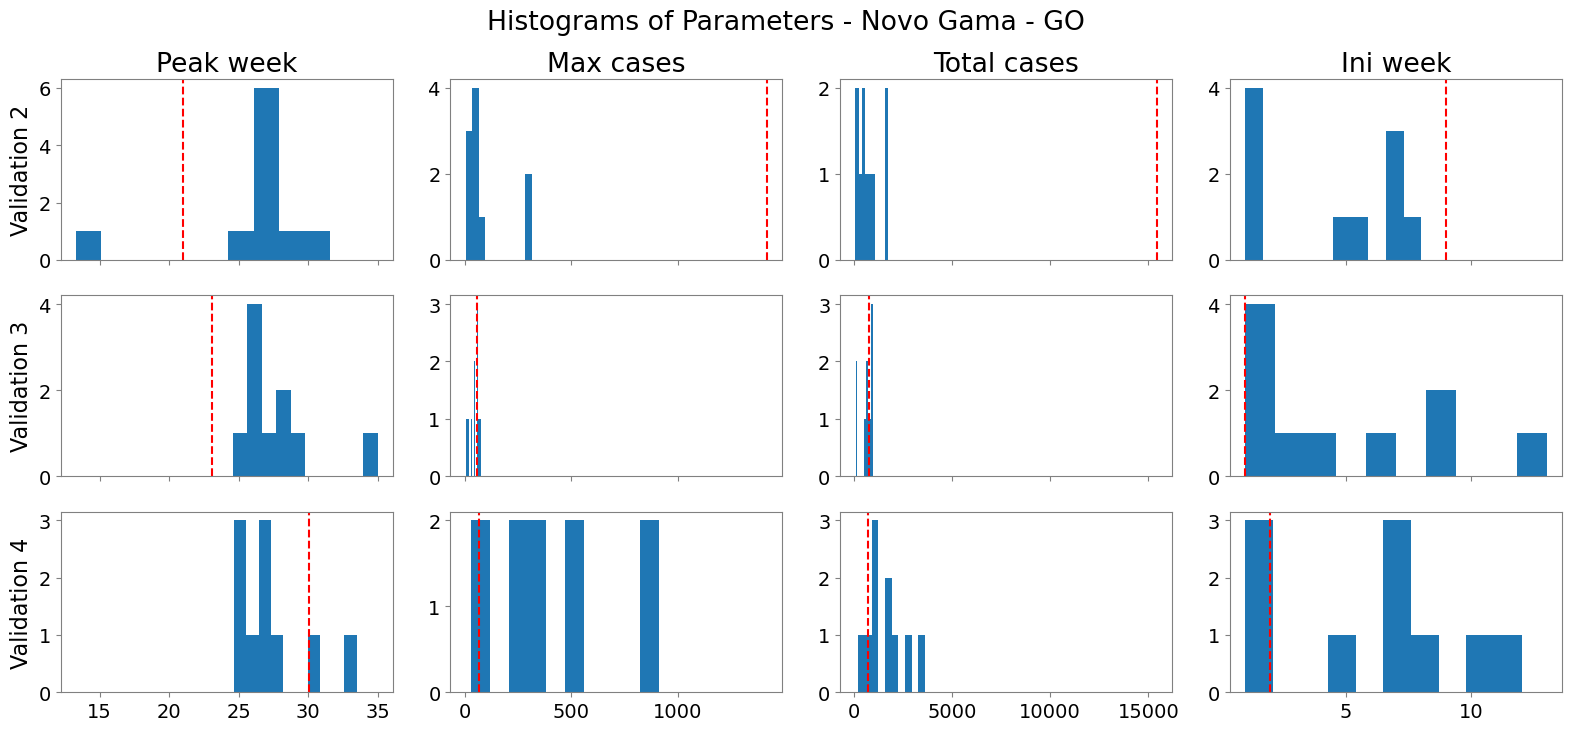

In [26]:
for geocode in df_preds.adm_2.unique():

    gname = df_summary.loc[df_summary.adm_2 == geocode]['adm_2_name'].values[0]


    fig, ax = plot_parameter_histograms(df_true_params,
        df_pars,
        region =geocode, label_title=gname, col_region = 'adm_2')
    
    plt.savefig(f'figures/hist_pars_{geocode}_{challenge}.png', dpi = 400, bbox_inches = 'tight')
    